# 1. Introduction

## 1.1 What models?

In [4]:
import os
from pathlib import Path

RESULTS_DIR = Path("results/FaceInThings")

models = [d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')]
models.sort()

print(f"Found {len(models)} models:")
for model in models:
    print(f"- {model}")

Found 8 models:
- Claude-Opus-4-7
- GPT-5.4
- Gemini-3.1-Pro
- Gemma3-26b
- Mistral-Small-4
- Qwen-3.5
- Qwen-HF
- Qwen3.5-9B


## 1.2 What setting?

In [25]:
import json
from pathlib import Path

RESULTS_DIR = Path("results/FaceInThings")
models = [d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')]
models.sort()

print("Step 1: Model Settings Summary\n" + "="*50)

for model in models:
    main_file = RESULTS_DIR / model / "main_results.jsonl"

    temperatures = set()
    runs = set()
    total_records = 0

    if main_file.exists():
        with open(main_file, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    data = json.loads(line)
                    if 'temperature' in data:
                        temperatures.add(data['temperature'])
                    if 'run_id' in data:
                        runs.add(data['run_id'])
                    total_records += 1
                except json.JSONDecodeError:
                    pass

    temps_list = sorted(list(temperatures))
    max_runs = max(runs) if runs else 0

    print(f"Model: {model}")
    print(f"  - Temperatures   : {temps_list}")
    print(f"  - Runs per image : {max_runs}")
    print(f"  - Total records  : {total_records}")
    print("-" * 50)

Step 1: Model Settings Summary
Model: Claude-Opus-4-7
  - Temperatures   : [1.0]
  - Runs per image : 1
  - Total records  : 2052
--------------------------------------------------
Model: GPT-5.4
  - Temperatures   : [1.0]
  - Runs per image : 1
  - Total records  : 4568
--------------------------------------------------
Model: Gemini-3.1-Pro
  - Temperatures   : [1.0]
  - Runs per image : 1
  - Total records  : 4483
--------------------------------------------------
Model: Gemma3-26b
  - Temperatures   : [0.0, 1.0]
  - Runs per image : 1
  - Total records  : 4823
--------------------------------------------------
Model: Mistral-Small-4
  - Temperatures   : [1.0]
  - Runs per image : 1
  - Total records  : 4827
--------------------------------------------------
Model: Qwen3.5-9B
  - Temperatures   : [1.0]
  - Runs per image : 1
  - Total records  : 2752
--------------------------------------------------


## 1.3 How? Which pipeline? What prompts?

In [9]:
import json

# =============================================================================
# PROMPT DEFINITIONS
# =============================================================================

DAT_PROMPT = """Please enter 10 words that are as different from each other as possible, in all meanings and uses of the words. Rules: Only single words in English. Only nouns (e.g., things, objects, concepts). No proper nouns (e.g., no specific people or places). No specialised vocabulary (e.g., no technical terms). Think of the words on your own (e.g., do not just look at objects in your surroundings).  Make a list of these 10 words, a single word in each entry of the list.
Output must be strict valid JSON only, with no extra text.
Schema:
{"words":["string","string","string","string","string","string","string","string","string","string"]}
Constraints:
- The array must contain exactly 10 entries.
- Do not output numbering, explanations, or markdown."""

IMAGE_PROMPT = """Look at the image.
Try to find hidden shapes or objects.
Describe each percept you found using one word per percept.
If the single word doesn't capture well what you've seen, you can add an optional description.
You will have to tell me where in the image you found the percept later. Output must be strictly valid JSON only, with no extra text.
Schema:
{"percepts":[{"label":"string","description":"string","confidence_present":0}]}
Constraints:
- "label" must be exactly one word.
- "description" must be a string. If unnecessary, use "".
- "confidence_present" must be a number from 0 to 100 indicating how confident you are that the percept is actually present in the image.
- If nothing is found, return {"percepts":[]}.
- Do not mention coordinates, regions, or explanations outside the JSON.
- Do not output markdown."""

# =============================================================================
# PRINT PROMPTS & 3-STEP PIPELINE ARCHITECTURE
# =============================================================================

print("=" * 80)
print("EXPERIMENTAL PIPELINE: 3-STEP FLOW & PROMPTS")
print("=" * 80)

print("\n" + "-" * 80)
print(">>> PROMPT A: DIVERGENT ASSOCIATION TASK (DAT_PROMPT)")
print("-" * 80)
print(DAT_PROMPT.strip())

print("\n" + "-" * 80)
print(">>> PROMPT B: VISUAL PAREIDOLIA (IMAGE_PROMPT)")
print("-" * 80)
print(IMAGE_PROMPT.strip())

print("\n" + "-" * 80)
print(">>> 3-STEP CONVERSATION FLOW (DAT -> IMAGE -> DAT)")
print("-" * 80)

pipeline_flow = {
    "step_1": {
        "name": "Baseline DAT (Control)",
        "prompt": "DAT_PROMPT",
        "input": "Text only (clean thread)",
        "output": "10 divergent nouns (JSON)"
    },
    "step_2": {
        "name": "Visual Pareidolia (Priming)",
        "prompt": "IMAGE_PROMPT",
        "input": "FacesInThings image + prompt",
        "output": "List of percepts with confidence ratings (JSON)"
    },
    "step_3": {
        "name": "Primed DAT (Post-Stimulus)",
        "prompt": "DAT_PROMPT",
        "input": "Follow-up in same conversational thread",
        "output": "10 primed divergent nouns (JSON)"
    }
}

print(json.dumps(pipeline_flow, indent=2))
print("=" * 80)

EXPERIMENTAL PIPELINE: 3-STEP FLOW & PROMPTS

--------------------------------------------------------------------------------
>>> PROMPT A: DIVERGENT ASSOCIATION TASK (DAT_PROMPT)
--------------------------------------------------------------------------------
Please enter 10 words that are as different from each other as possible, in all meanings and uses of the words. Rules: Only single words in English. Only nouns (e.g., things, objects, concepts). No proper nouns (e.g., no specific people or places). No specialised vocabulary (e.g., no technical terms). Think of the words on your own (e.g., do not just look at objects in your surroundings).  Make a list of these 10 words, a single word in each entry of the list.
Output must be strict valid JSON only, with no extra text.
Schema:
{"words":["string","string","string","string","string","string","string","string","string","string"]}
Constraints:
- The array must contain exactly 10 entries.
- Do not output numbering, explanations, or ma

## 1.4 What dataset?

DATASET OVERVIEW: FACES IN THINGS
Directory Path        : /Users/precioux/Desktop/Projects/Creativity/FacesInThings/images
Total Valid Images    : 4827
Image Formats Found   : {'.jpg': 4827}
Mean Resolution       : 512 x 512 px
Resolution Range      : [512x512] to [512x512]


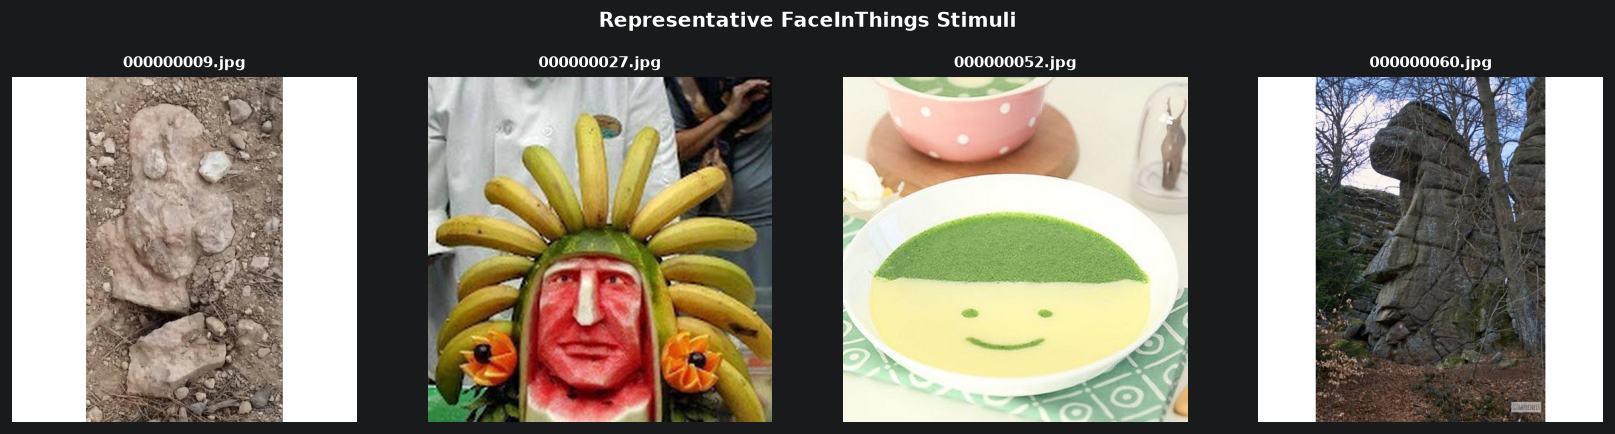

In [10]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# Dataset path resolution
CANDIDATE_PATHS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]

IMAGE_DIR = None
for p in CANDIDATE_PATHS:
    if p.exists() and any(p.iterdir()):
        IMAGE_DIR = p
        break

if not IMAGE_DIR:
    raise FileNotFoundError("Could not find the FacesInThings images directory.")

image_extensions = ("*.png", "*.jpg", "*.jpeg", "*.webp")
image_files = []
for ext in image_extensions:
    image_files.extend(IMAGE_DIR.glob(ext))
image_files = sorted(image_files)

dataset_records = []
for img_p in image_files:
    try:
        with Image.open(img_p) as im:
            w, h = im.size
            mode = im.mode
            ext = img_p.suffix.lower()
        dataset_records.append({
            "File Name": img_p.name,
            "Width": w,
            "Height": h,
            "Mode": mode,
            "Format": ext
        })
    except Exception:
        continue

df_dataset = pd.DataFrame(dataset_records)

print("=" * 75)
print("DATASET OVERVIEW: FACES IN THINGS")
print("=" * 75)
print(f"Directory Path        : {IMAGE_DIR}")
print(f"Total Valid Images    : {len(df_dataset)}")
if not df_dataset.empty:
    print(f"Image Formats Found   : {df_dataset['Format'].value_counts().to_dict()}")
    print(f"Mean Resolution       : {df_dataset['Width'].mean():.0f} x {df_dataset['Height'].mean():.0f} px")
    print(f"Resolution Range      : [{df_dataset['Width'].min()}x{df_dataset['Height'].min()}] to [{df_dataset['Width'].max()}x{df_dataset['Height'].max()}]")
print("=" * 75)

# Display 4 representative stimulus images
if len(image_files) >= 4:
    samples = image_files[:4]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=120)
    for idx, (img_p, ax) in enumerate(zip(samples, axes)):
        with Image.open(img_p) as im:
            ax.imshow(im)
            ax.set_title(f"{img_p.name}", fontsize=9, fontweight='bold')
            ax.axis("off")
    plt.suptitle("Representative FaceInThings Stimuli", fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 2. Models

## 2.1 Gemini-3.1-Pro

DIAGNOSTIC INSPECTION: Gemini-3.1-Pro (FaceInThings)
Results Directory    : results/FaceInThings/Gemini-3.1-Pro
Main Results File    : results/FaceInThings/Gemini-3.1-Pro/main_results.jsonl (Exists: True)
Baseline File        : results/FaceInThings/Gemini-3.1-Pro/dat_baseline_results.jsonl (Exists: True)
Baseline Records Loaded : 1
Main Runs Completed     : 4483

SAMPLE RUN INSPECTION: File=000000009.jpg | Temp=1.0 | Run ID=1


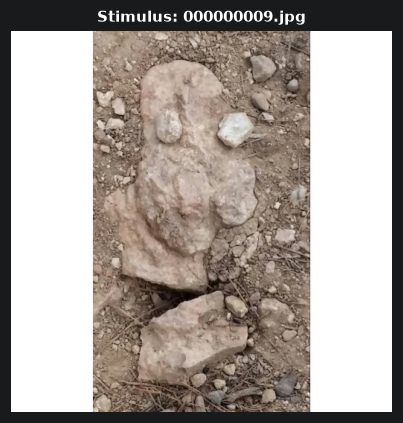


>>> STEP 1: BASELINE DAT (CONTROL)
--------------------------------------------------
Words: ['appetite', 'galaxy', 'melody', 'oxygen', 'reptile', 'democracy', 'skyscraper', 'blizzard', 'triangle', 'afternoon']

>>> STEP 2: TURN 1 - VISUAL PAREIDOLIA
--------------------------------------------------
Percepts Found (3):
  - Label: face            | Conf: 95   | Desc: A large rock formation with two smaller rocks resting on it acting as eyes, giving the appearance of a face.
  - Label: rocks           | Conf: 100  | Desc: Various smaller rocks and pebbles scattered on the ground around the main formation.
  - Label: dirt            | Conf: 100  | Desc: The soil and ground covering the area around the rocks.

>>> STEP 3: TURN 2 - PRIMED DAT (SAME THREAD)
--------------------------------------------------
Words: ['justice', 'galaxy', 'shoe', 'elephant', 'symphony', 'velvet', 'ocean', 'century', 'carrot', 'elbow']


In [11]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

MODEL_NAME = "Gemini-3.1-Pro"
DATASET_NAME = "FaceInThings"

# Candidate paths for the FaceInThings images directory
CANDIDATE_IMG_DIRS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]
IMAGE_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists() and any(p.iterdir())), None)

RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"
baseline_file = RESULTS_DIR / "dat_baseline_results.jsonl"

print("=" * 80)
print(f"DIAGNOSTIC INSPECTION: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 80)
print(f"Results Directory    : {RESULTS_DIR}")
print(f"Main Results File    : {main_file} (Exists: {main_file.exists()})")
print(f"Baseline File        : {baseline_file} (Exists: {baseline_file.exists()})")

# 1. Load baseline records
baseline_records = []
if baseline_file.exists():
    with open(baseline_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    baseline_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

# 2. Load main records
main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

print(f"Baseline Records Loaded : {len(baseline_records)}")
print(f"Main Runs Completed     : {len(main_records)}")

# 3. Inspect a sample execution
if main_records:
    sample = main_records[0]
    img_filename = sample.get("file")
    temp = sample.get("temperature", 1.0)
    run_id = sample.get("run_id", 1)

    # Locate baseline corresponding to this temperature
    sample_baseline = next((b for b in baseline_records if b.get("temperature") == temp), None)
    if not sample_baseline and baseline_records:
        sample_baseline = baseline_records[0]

    print("\n" + "=" * 80)
    print(f"SAMPLE RUN INSPECTION: File={img_filename} | Temp={temp} | Run ID={run_id}")
    print("=" * 80)

    # Show image if accessible
    if IMAGE_DIR and (IMAGE_DIR / img_filename).exists():
        img_path = IMAGE_DIR / img_filename
        fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=110)
        im = Image.open(img_path)
        ax.imshow(im)
        ax.set_title(f"Stimulus: {img_filename}", fontweight="bold", fontsize=10)
        ax.axis("off")
        plt.show()
    else:
        print(f"[Image file '{img_filename}' not found in candidate paths]")

    # Step 1: Baseline DAT
    print("\n>>> STEP 1: BASELINE DAT (CONTROL)")
    print("-" * 50)
    if sample_baseline and sample_baseline.get("dat_parsed"):
        print("Words:", sample_baseline["dat_parsed"].get("words", []))
    else:
        print("No baseline record available for this condition.")

    # Step 2: Turn 1 (Visual Pareidolia)
    print("\n>>> STEP 2: TURN 1 - VISUAL PAREIDOLIA")
    print("-" * 50)
    img_parsed = sample.get("image_parsed") or sample.get("fractal_parsed") or {}
    percepts = img_parsed.get("percepts", [])
    print(f"Percepts Found ({len(percepts)}):")
    for p in percepts:
        lbl = p.get("label", "")
        conf = p.get("confidence_present", "")
        desc = p.get("description", "")
        print(f"  - Label: {lbl:<15} | Conf: {str(conf):<4} | Desc: {desc}")

    # Step 3: Turn 2 (Primed DAT)
    print("\n>>> STEP 3: TURN 2 - PRIMED DAT (SAME THREAD)")
    print("-" * 50)
    dat_parsed = sample.get("dat_parsed", {})
    print("Words:", dat_parsed.get("words", []))
    print("=" * 80)
else:
    print("\nNo records found in main_results.jsonl to display.")

#### Experiment Analysis:

In [21]:
import json
from pathlib import Path

MODEL_NAME = "Gemini-3.1-Pro"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

# Resolve FaceInThings image directory
CANDIDATE_IMG_DIRS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]
IMAGE_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists() and any(p.iterdir())), None)

# FaceInThings setup: temp=1.0 and 1 run per image
TEMPERATURES = [1.0]
NUM_RUNS = 1

images = []
if IMAGE_DIR and IMAGE_DIR.exists():
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.webp"):
        images.extend(IMAGE_DIR.glob(ext))
images = sorted(images)

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((float(data['temperature']), data['file'], int(data['run_id'])))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print("=" * 60)
print(f"STEP 2: EXECUTION PROGRESS & AUDIT ﷿﷿﷿ {MODEL_NAME} ({DATASET_NAME})")
print("=" * 60)
print(f"Image Directory       : {IMAGE_DIR}")
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("=" * 60)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

STEP 2: EXECUTION PROGRESS & AUDIT ﷿﷿﷿ Gemini-3.1-Pro (FaceInThings)
Image Directory       : /Users/precioux/Desktop/Projects/Creativity/FacesInThings/images
Total Images Found    : 4827
Expected Runs (Total) : 4827
Completed Runs        : 4483
Missing Runs          : 344
Completion Rate       : 92.87%

Sample of missing runs (showing up to 5):
- Temp: 1.0 | File: 000025912.jpg | Run ID: 1
- Temp: 1.0 | File: 000007014.jpg | Run ID: 1
- Temp: 1.0 | File: 000013017.jpg | Run ID: 1
- Temp: 1.0 | File: 000027430.jpg | Run ID: 1
- Temp: 1.0 | File: 000010125.jpg | Run ID: 1


#### Vocab Analysis:

In [24]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from itertools import combinations
from scipy.stats import entropy

MODEL_NAME = "Gemini-3.1-Pro"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

main_file = RESULTS_DIR / "main_results.jsonl"
base_file = RESULTS_DIR / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file} to analyze.")

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def get_percept_labels(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        return [str(p.get('label', '')).lower().strip() for p in parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        confs = []
        for p in parsed['percepts']:
            if isinstance(p, dict):
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
        if confs:
            return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['parsed_stimulus'] = df_main.apply(extract_image_parsed, axis=1)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['parsed_stimulus'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['parsed_stimulus'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp:
        return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

def calc_image_consistency(labels_list_of_runs):
    valid_runs = [set(labels) for labels in labels_list_of_runs if labels]
    if len(valid_runs) < 2:
        return np.nan
    sims = []
    for s1, s2 in combinations(valid_runs, 2):
        union = len(s1.union(s2))
        sims.append(len(s1.intersection(s2)) / union if union > 0 else 1.0)
    return np.mean(sims) if sims else np.nan

consistency_results = []
for (temp, file), group in df_main.groupby(['temperature', 'file']):
    score = calc_image_consistency(group['percept_labels'].tolist())
    consistency_results.append({
        'temperature': temp,
        'file': file,
        'consistency_score': score
    })
df_consistency = pd.DataFrame(consistency_results)

print("=" * 75)
print(f"ANALYSIS SUMMARY: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 75)

all_primed_words = [w for wlist in df_main['dat_words'] for w in wlist]
print("\n1. VOCABULARY SIZE:")
print(f"  - Total Tokens Emitted   : {len(all_primed_words):,}")
print(f"  - Unique Distinct Words  : {len(set(all_primed_words)):,}")
base_vocab_count = len(set([w for ws in df_base['dat_words'] for w in ws])) if not df_base.empty else 0
print(f"  - Baseline Distinct Words: {base_vocab_count:,}")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())

print("\n4. PAREIDOLIA PERCEPT CONSISTENCY:")
valid_cons = df_consistency['consistency_score'].dropna()
if not valid_cons.empty:
    print(f"  - Mean Jaccard Consistency: {valid_cons.mean():.4f}")
else:
    print("  - Single run per image detected (consistency requires >= 2 runs per image).")
print("=" * 75)

ANALYSIS SUMMARY: Gemini-3.1-Pro (FaceInThings)

1. VOCABULARY SIZE:
  - Total Tokens Emitted   : 44,820
  - Unique Distinct Words  : 829
  - Baseline Distinct Words: 10

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 1.0: 89.95%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
1.0               9.9978  0.9998           0.0002           0.8214   2.3021

4. PAREIDOLIA PERCEPT CONSISTENCY:
  - Single run per image detected (consistency requires >= 2 runs per image).


#### Perception Analysis:

PERCEPTION PROFILE: Gemini-3.1-Pro (FaceInThings @ Temp 1.0)
Total Evaluated Stimuli       : 4483
Pareidolia Detection Rate     : 99.82% (4475/4483 images)
Total Percepts Discovered     : 22,051
Unique Distinct Labels        : 1,630
Mean Percepts per Stimulus    : 4.92 (std: 19.16)
Mean Percept Confidence       : 86.00% (median: 95.00%)
---------------------------------------------------------------------------


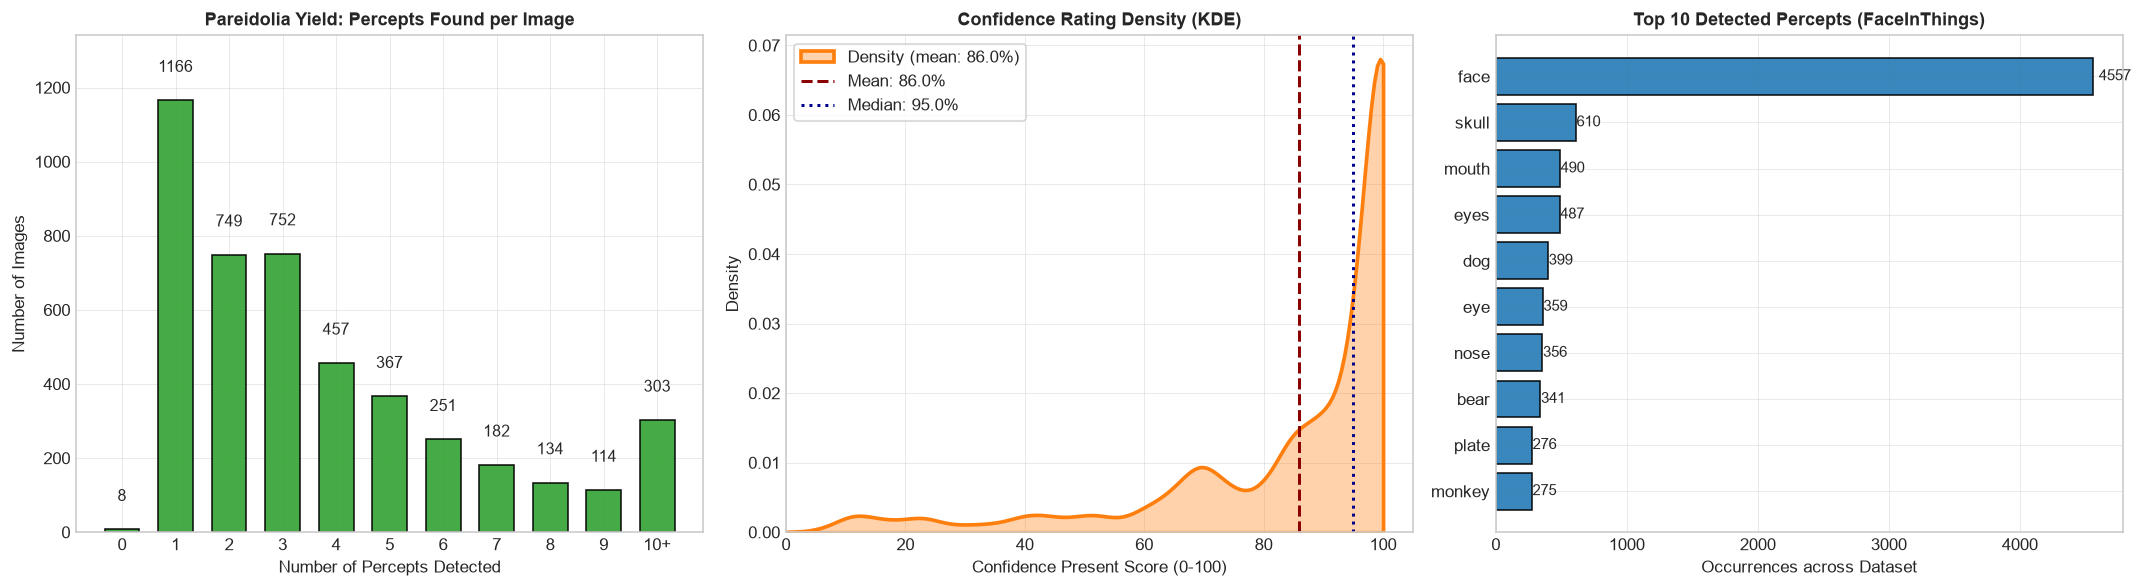

In [31]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Gemini-3.1-Pro"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_info(row):
    parsed = extract_image_parsed(row)
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, confs, mean_conf

df_main['extracted_info'] = df_main.apply(extract_percept_info, axis=1)
df_main['percept_labels'] = [x[0] for x in df_main['extracted_info']]
df_main['confidence_list'] = [x[1] for x in df_main['extracted_info']]
df_main['mean_confidence'] = [x[2] for x in df_main['extracted_info']]
df_main['percept_count'] = df_main['percept_labels'].apply(len)
df_main['has_percept'] = df_main['percept_count'] > 0

all_labels = [lbl for labels in df_main['percept_labels'] for lbl in labels]
all_confs = [c for clist in df_main['confidence_list'] for c in clist]
label_counts = Counter(all_labels)

total_images = len(df_main)
detected_images = df_main['has_percept'].sum()
detection_rate = (detected_images / total_images) * 100 if total_images > 0 else 0

print("=" * 75)
print(f"PERCEPTION PROFILE: {MODEL_NAME} ({DATASET_NAME} @ Temp 1.0)")
print("=" * 75)
print(f"Total Evaluated Stimuli       : {total_images}")
print(f"Pareidolia Detection Rate     : {detection_rate:.2f}% ({detected_images}/{total_images} images)")
print(f"Total Percepts Discovered     : {len(all_labels):,}")
print(f"Unique Distinct Labels        : {len(label_counts):,}")
print(f"Mean Percepts per Stimulus    : {df_main['percept_count'].mean():.2f} (std: {df_main['percept_count'].std():.2f})")
print(f"Mean Percept Confidence       : {np.mean(all_confs):.2f}% (median: {np.median(all_confs):.2f}%)")
print("-" * 75)

MAX_BINS = 10
def bin_counts(val):
    if val >= MAX_BINS:
        return f"{MAX_BINS}+"
    return str(val)

df_main['percept_binned'] = df_main['percept_count'].apply(bin_counts)
bin_labels = [str(i) for i in range(MAX_BINS)] + [f"{MAX_BINS}+"]
binned_series = df_main['percept_binned'].value_counts().reindex(bin_labels, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

bars = axes[0].bar(binned_series.index, binned_series.values, color='#2ca02c', edgecolor='black', alpha=0.88, width=0.65)
axes[0].set_title("Pareidolia Yield: Percepts Found per Image", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Number of Percepts Detected", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2.0, h + max(5, total_images * 0.015), f"{h}", ha='center', va='bottom', fontsize=9.5)
axes[0].set_ylim(0, max(binned_series.values) * 1.15)

if all_confs:
    sns.kdeplot(
        all_confs,
        ax=axes[1],
        color='#ff7f0e',
        linewidth=2.2,
        fill=True,
        alpha=0.35,
        clip=(0, 100),
        label=f"Density (mean: {np.mean(all_confs):.1f}%)"
    )
axes[1].axvline(np.mean(all_confs), color='darkred', linestyle='--', linewidth=1.8, label=f"Mean: {np.mean(all_confs):.1f}%")
axes[1].axvline(np.median(all_confs), color='darkblue', linestyle=':', linewidth=1.8, label=f"Median: {np.median(all_confs):.1f}%")
axes[1].set_title("Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Confidence Present Score (0-100)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].set_xlim(0, 105)
axes[1].legend(frameon=True)

top_10 = pd.DataFrame(label_counts.most_common(10), columns=['Label', 'Count'])
axes[2].barh(top_10['Label'][::-1], top_10['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.88)
axes[2].set_title("Top 10 Detected Percepts (FaceInThings)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Occurrences across Dataset", fontsize=10)
for idx, row in enumerate(top_10.iloc[::-1].itertuples()):
    axes[2].text(row.Count + max(5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Left Experiments:

In [32]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

ACTIVITY_FILE = "../openrouter_activity_2026-06-27.csv"
MODEL_NAME = "google/gemini-3.1-pro-preview"
DATASET_NAME = "FaceInThings"

# Candidate paths for the FaceInThings images directory
CANDIDATE_IMG_DIRS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]
IMAGE_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists() and any(p.iterdir())), None)

# Determine total image count dynamically
if IMAGE_DIR and IMAGE_DIR.exists():
    found_images = [p for ext in ("*.png", "*.jpg", "*.jpeg", "*.webp") for p in IMAGE_DIR.glob(ext)]
    TOTAL_IMAGES = len(found_images)
else:
    # Fallback to unique images recorded in main_results.jsonl if image folder is not local
    main_file = Path("results") / DATASET_NAME / "Gemini-3.1-Pro" / "main_results.jsonl"
    if main_file.exists():
        with open(main_file, "r", encoding="utf-8") as f:
            unique_imgs = {json.loads(line)["file"] for line in f if line.strip()}
        TOTAL_IMAGES = len(unique_imgs)
    else:
        TOTAL_IMAGES = 3271

# FaceInThings setup: 1 temperature, 1 run per image, baseline runs
TEMPERATURES_COUNT = 1
RUNS_PER_IMAGE = 1
DAT_BASELINE_RUNS = 10

total_expected_runs = TOTAL_IMAGES * TEMPERATURES_COUNT * RUNS_PER_IMAGE
total_expected_calls = (total_expected_runs * 2) + (TEMPERATURES_COUNT * DAT_BASELINE_RUNS)

df_act = pd.read_csv(ACTIVITY_FILE)

# Filter records for Gemini-3.1-Pro
gemini_mask = df_act['model_permaslug'].str.contains('gemini-3.1-pro', case=False, na=False)
df_gemini = df_act[gemini_mask].copy()

total_completed_calls = len(df_gemini)
total_prompt_tokens = df_gemini['tokens_prompt'].sum()
total_completion_tokens = df_gemini['tokens_completion'].sum()
total_tokens = total_prompt_tokens + total_completion_tokens
total_cost = df_gemini['cost_total'].sum()

mean_prompt_per_call = df_gemini['tokens_prompt'].mean() if len(df_gemini) > 0 else 0
mean_comp_per_call = df_gemini['tokens_completion'].mean() if len(df_gemini) > 0 else 0
mean_cost_per_call = df_gemini['cost_total'].mean() if len(df_gemini) > 0 else 0

missing_calls = max(0, total_expected_calls - total_completed_calls)
missing_runs = missing_calls // 2

est_missing_prompt_tokens = int(missing_calls * mean_prompt_per_call)
est_missing_comp_tokens = int(missing_calls * mean_comp_per_call)
est_missing_total_tokens = est_missing_prompt_tokens + est_missing_comp_tokens
est_missing_cost = missing_calls * mean_cost_per_call

print("=" * 65)
print(f"TOKEN USAGE & BUDGET ESTIMATION (Gemini-3.1-Pro ﷿﷿﷿ {DATASET_NAME})")
print("=" * 65)
print(f"Total Stimulus Images         : {TOTAL_IMAGES:,}")
print(f"Total Completed API Calls     : {total_completed_calls:,}")
print(f"Total Prompt Tokens Used      : {total_prompt_tokens:,}")
print(f"Total Completion Tokens Used  : {total_completion_tokens:,}")
print(f"Total Tokens Consumed         : {total_tokens:,}")
print(f"Total Cost Spent              : ${total_cost:,.2f}")
print("-" * 65)
print(f"Mean Prompt Tokens / Call     : {mean_prompt_per_call:,.1f}")
print(f"Mean Completion Tokens / Call : {mean_comp_per_call:,.1f}")
print(f"Mean Cost / Call              : ${mean_cost_per_call:,.4f}")
print(f"Mean Cost / Full Run (2 calls): ${mean_cost_per_call * 2:,.4f}")
print("-" * 65)
print(f"Total Expected API Calls      : {total_expected_calls:,}")
print(f"Remaining Missing Calls       : {missing_calls:,} (~{missing_runs:,} runs)")
print(f"Estimated Missing Tokens      : {est_missing_total_tokens:,}")
print(f"Estimated Cost to Complete    : ${est_missing_cost:,.2f}")
print("=" * 65)

TOKEN USAGE & BUDGET ESTIMATION (Gemini-3.1-Pro ﷿﷿﷿ FaceInThings)
Total Stimulus Images         : 4,827
Total Completed API Calls     : 9,025
Total Prompt Tokens Used      : 13,559,983
Total Completion Tokens Used  : 11,101,850
Total Tokens Consumed         : 24,661,833
Total Cost Spent              : $160.34
-----------------------------------------------------------------
Mean Prompt Tokens / Call     : 1,502.5
Mean Completion Tokens / Call : 1,230.1
Mean Cost / Call              : $0.0178
Mean Cost / Full Run (2 calls): $0.0355
-----------------------------------------------------------------
Total Expected API Calls      : 9,664
Remaining Missing Calls       : 639 (~319 runs)
Estimated Missing Tokens      : 1,746,138
Estimated Cost to Complete    : $11.35


## 2.2 Claude-Opus-4.7

#### Example:

STEP 1: EXAMPLE RUN INSPECTION ﷿﷿﷿ Claude-Opus-4-7 (FaceInThings)


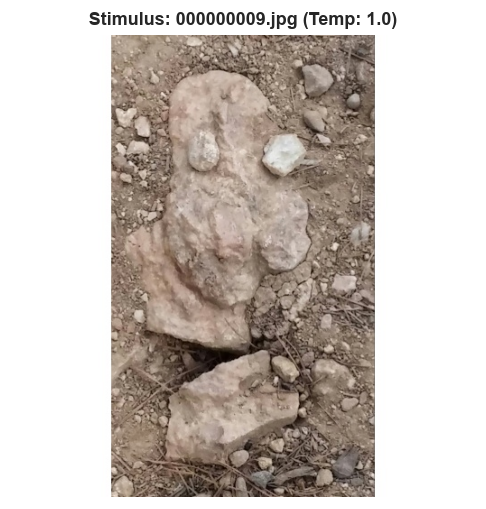


--------------------------------------------------------------------------------
1. BASELINE DAT (Control ﷿﷿﷿ No Visual Input):
--------------------------------------------------------------------------------
Words (10): ['mountain', 'whisper', 'justice', 'umbrella', 'barnacle', 'rhythm', 'sandwich', 'gravity', 'freedom', 'cactus']

--------------------------------------------------------------------------------
2. VISUAL PAREIDOLIA PERCEPTS (Turn 1):
--------------------------------------------------------------------------------
Total Percepts Detected: 7
  [01] Label: figure          | Confidence: 70   | Description: rock resembling a humanoid or torso shape
  [02] Label: face            | Confidence: 55   | Description: upper rock suggests a face-like form
  [03] Label: skull           | Confidence: 40   | Description: pareidolia of a skull shape
  [04] Label: owl             | Confidence: 45   | Description: upper portion resembles an owl with eyes
  [05] Label: heart           |

In [33]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

MODEL_NAME = "Claude-Opus-4-7"
DATASET_NAME = "FaceInThings"

CANDIDATE_IMG_DIRS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]
IMAGE_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists() and any(p.iterdir())), None)

RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"
baseline_file = RESULTS_DIR / "dat_baseline_results.jsonl"

baseline_records = []
if baseline_file.exists():
    with open(baseline_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    baseline_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

main_records = []
if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

print("=" * 80)
print(f"STEP 1: EXAMPLE RUN INSPECTION ﷿﷿﷿ {MODEL_NAME} ({DATASET_NAME})")
print("=" * 80)

if not main_records:
    print(f"No records found in {main_file}")
else:
    sample = main_records[0]
    img_filename = sample.get("file")
    temp = sample.get("temperature", 1.0)
    run_id = sample.get("run_id", 1)

    # 1. Display stimulus image
    if IMAGE_DIR and (IMAGE_DIR / img_filename).exists():
        img_path = IMAGE_DIR / img_filename
        fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
        im = Image.open(img_path)
        ax.imshow(im)
        ax.set_title(f"Stimulus: {img_filename} (Temp: {temp})", fontweight="bold", fontsize=11)
        ax.axis("off")
        plt.show()
    else:
        print(f"[Image file '{img_filename}' not found locally]")

    # 2. Baseline DAT (Control)
    print("\n" + "-" * 80)
    print("1. BASELINE DAT (Control ﷿﷿﷿ No Visual Input):")
    print("-" * 80)
    base_sample = next((b for b in baseline_records if b.get("temperature") == temp), None)
    if not base_sample and baseline_records:
        base_sample = baseline_records[0]

    if base_sample and base_sample.get("dat_parsed"):
        base_words = base_sample["dat_parsed"].get("words", [])
        print(f"Words ({len(base_words)}): {base_words}")
    else:
        print("No baseline record available.")

    # 3. Turn 1: Pareidolia Perception
    print("\n" + "-" * 80)
    print("2. VISUAL PAREIDOLIA PERCEPTS (Turn 1):")
    print("-" * 80)
    img_parsed = sample.get("image_parsed") or sample.get("fractal_parsed") or {}
    percepts = img_parsed.get("percepts", [])
    print(f"Total Percepts Detected: {len(percepts)}")
    for idx, p in enumerate(percepts, 1):
        lbl = p.get("label", "")
        conf = p.get("confidence_present", "")
        desc = p.get("description", "")
        print(f"  [{idx:02d}] Label: {lbl:<15} | Confidence: {str(conf):<4} | Description: {desc}")

    # 4. Turn 2: Primed DAT
    print("\n" + "-" * 80)
    print("3. PRIMED DAT (Turn 2 ﷿﷿﷿ Same Thread Context):")
    print("-" * 80)
    dat_parsed = sample.get("dat_parsed", {})
    primed_words = dat_parsed.get("words", []) if dat_parsed else []
    print(f"Words ({len(primed_words)}): {primed_words}")
    print("=" * 80)

#### Experiment Analysis:

In [34]:
import json
from pathlib import Path

MODEL_NAME = "Claude-Opus-4-7"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

CANDIDATE_IMG_DIRS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]
IMAGE_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists() and any(p.iterdir())), None)

TEMPERATURES = [1.0]
NUM_RUNS = 1

images = []
if IMAGE_DIR and IMAGE_DIR.exists():
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.webp"):
        images.extend(IMAGE_DIR.glob(ext))
images = sorted(images)

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((float(data['temperature']), data['file'], int(data['run_id'])))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print("=" * 60)
print(f"STEP 2: EXECUTION PROGRESS & AUDIT ﷿﷿﷿ {MODEL_NAME} ({DATASET_NAME})")
print("=" * 60)
print(f"Image Directory       : {IMAGE_DIR}")
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("=" * 60)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

STEP 2: EXECUTION PROGRESS & AUDIT ﷿﷿﷿ Claude-Opus-4-7 (FaceInThings)
Image Directory       : /Users/precioux/Desktop/Projects/Creativity/FacesInThings/images
Total Images Found    : 4827
Expected Runs (Total) : 4827
Completed Runs        : 2052
Missing Runs          : 2775
Completion Rate       : 42.51%

Sample of missing runs (showing up to 5):
- Temp: 1.0 | File: 000018410.jpg | Run ID: 1
- Temp: 1.0 | File: 000025912.jpg | Run ID: 1
- Temp: 1.0 | File: 000025389.jpg | Run ID: 1
- Temp: 1.0 | File: 000021308.jpg | Run ID: 1
- Temp: 1.0 | File: 000011167.jpg | Run ID: 1


#### Perception Analysis:

In [35]:
import json
from pathlib import Path

MODEL_NAME = "Claude-Opus-4-7"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

CANDIDATE_IMG_DIRS = [
    Path("/Users/precioux/Desktop/Projects/Creativity/FacesInThings/images"),
    Path("../FacesInThings/images"),
    Path("FacesInThings/images"),
    Path("images")
]
IMAGE_DIR = next((p for p in CANDIDATE_IMG_DIRS if p.exists() and any(p.iterdir())), None)

TEMPERATURES = [1.0]
NUM_RUNS = 1

images = []
if IMAGE_DIR and IMAGE_DIR.exists():
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.webp"):
        images.extend(IMAGE_DIR.glob(ext))
images = sorted(images)

expected_combos = set((temp, img.name, run_id) for img in images for temp in TEMPERATURES for run_id in range(1, NUM_RUNS + 1))

main_file = RESULTS_DIR / "main_results.jsonl"
completed_combos = set()

if main_file.exists():
    with open(main_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                if 'temperature' in data and 'file' in data and 'run_id' in data:
                    completed_combos.add((float(data['temperature']), data['file'], int(data['run_id'])))
            except json.JSONDecodeError:
                pass

missing_combos = expected_combos - completed_combos

print("=" * 60)
print(f"STEP 2: EXECUTION PROGRESS & AUDIT ﷿﷿﷿ {MODEL_NAME} ({DATASET_NAME})")
print("=" * 60)
print(f"Image Directory       : {IMAGE_DIR}")
print(f"Total Images Found    : {len(images)}")
print(f"Expected Runs (Total) : {len(expected_combos)}")
print(f"Completed Runs        : {len(completed_combos)}")
print(f"Missing Runs          : {len(missing_combos)}")
percentage = (len(completed_combos) / len(expected_combos)) * 100 if expected_combos else 0
print(f"Completion Rate       : {percentage:.2f}%")
print("=" * 60)

if missing_combos:
    print("\nSample of missing runs (showing up to 5):")
    for m in list(missing_combos)[:5]:
        print(f"- Temp: {m[0]} | File: {m[1]} | Run ID: {m[2]}")
else:
    print("\nAll expected runs are 100% completed!")

STEP 2: EXECUTION PROGRESS & AUDIT ﷿﷿﷿ Claude-Opus-4-7 (FaceInThings)
Image Directory       : /Users/precioux/Desktop/Projects/Creativity/FacesInThings/images
Total Images Found    : 4827
Expected Runs (Total) : 4827
Completed Runs        : 2052
Missing Runs          : 2775
Completion Rate       : 42.51%

Sample of missing runs (showing up to 5):
- Temp: 1.0 | File: 000018410.jpg | Run ID: 1
- Temp: 1.0 | File: 000025912.jpg | Run ID: 1
- Temp: 1.0 | File: 000025389.jpg | Run ID: 1
- Temp: 1.0 | File: 000021308.jpg | Run ID: 1
- Temp: 1.0 | File: 000011167.jpg | Run ID: 1


In [36]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Claude-Opus-4-7"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

main_file = RESULTS_DIR / "main_results.jsonl"
base_file = RESULTS_DIR / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def get_percept_labels(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        return [str(p.get('label', '')).lower().strip() for p in parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        confs = []
        for p in parsed['percepts']:
            if isinstance(p, dict):
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
        if confs:
            return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['parsed_stimulus'] = df_main.apply(extract_image_parsed, axis=1)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['parsed_stimulus'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['parsed_stimulus'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp:
        return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

print("=" * 75)
print(f"VOCABULARY ANALYSIS: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 75)

all_primed_words = [w for wlist in df_main['dat_words'] for w in wlist]
print("\n1. OVERALL VOCABULARY SIZE:")
print(f"  - Total Tokens Produced : {len(all_primed_words):,}")
print(f"  - Unique Vocabulary Size: {len(set(all_primed_words)):,}")
base_vocab_count = len(set([w for ws in df_base['dat_words'] for w in ws])) if not df_base.empty else 0
print(f"  - Baseline Distinct Words: {base_vocab_count:,}")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())
print("=" * 75)

VOCABULARY ANALYSIS: Claude-Opus-4-7 (FaceInThings)

1. OVERALL VOCABULARY SIZE:
  - Total Tokens Produced : 20,520
  - Unique Vocabulary Size: 425
  - Baseline Distinct Words: 10

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 1.0: 79.23%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words  ttr  repetition_rate  novel_word_prop  entropy
temperature                                                             
1.0                 10.0  1.0              0.0           0.7679   2.3026


PERCEPTION PROFILE: Claude-Opus-4-7 (FaceInThings @ Temp 1.0)
Total Evaluated Stimuli       : 2052
Pareidolia Detection Rate     : 99.95% (2051/2052 images)
Total Percepts Discovered     : 14,079
Unique Distinct Labels        : 1,676
Mean Percepts per Stimulus    : 6.86 (std: 1.40)
Mean Percept Confidence       : 80.18% (median: 85.00%)
---------------------------------------------------------------------------


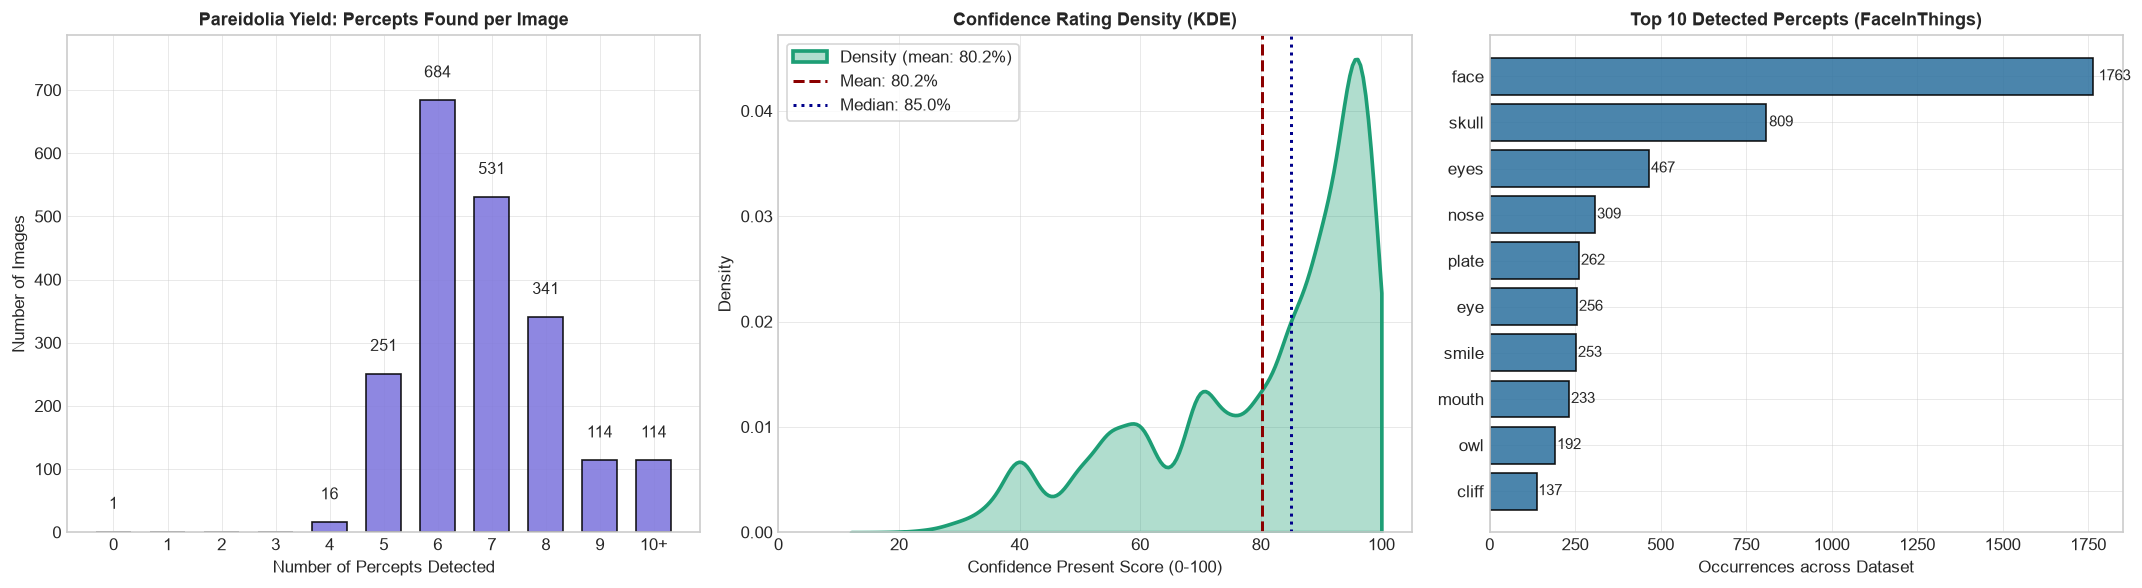

In [37]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Claude-Opus-4-7"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_info(row):
    parsed = extract_image_parsed(row)
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, confs, mean_conf

df_main['extracted_info'] = df_main.apply(extract_percept_info, axis=1)
df_main['percept_labels'] = [x[0] for x in df_main['extracted_info']]
df_main['confidence_list'] = [x[1] for x in df_main['extracted_info']]
df_main['mean_confidence'] = [x[2] for x in df_main['extracted_info']]
df_main['percept_count'] = df_main['percept_labels'].apply(len)
df_main['has_percept'] = df_main['percept_count'] > 0

all_labels = [lbl for labels in df_main['percept_labels'] for lbl in labels]
all_confs = [c for clist in df_main['confidence_list'] for c in clist]
label_counts = Counter(all_labels)

total_images = len(df_main)
detected_images = df_main['has_percept'].sum()
detection_rate = (detected_images / total_images) * 100 if total_images > 0 else 0

print("=" * 75)
print(f"PERCEPTION PROFILE: {MODEL_NAME} ({DATASET_NAME} @ Temp 1.0)")
print("=" * 75)
print(f"Total Evaluated Stimuli       : {total_images}")
print(f"Pareidolia Detection Rate     : {detection_rate:.2f}% ({detected_images}/{total_images} images)")
print(f"Total Percepts Discovered     : {len(all_labels):,}")
print(f"Unique Distinct Labels        : {len(label_counts):,}")
print(f"Mean Percepts per Stimulus    : {df_main['percept_count'].mean():.2f} (std: {df_main['percept_count'].std():.2f})")
if all_confs:
    print(f"Mean Percept Confidence       : {np.mean(all_confs):.2f}% (median: {np.median(all_confs):.2f}%)")
print("-" * 75)

# Binning outliers at 10+
MAX_BINS = 10
def bin_counts(val):
    if val >= MAX_BINS:
        return f"{MAX_BINS}+"
    return str(val)

df_main['percept_binned'] = df_main['percept_count'].apply(bin_counts)
bin_labels = [str(i) for i in range(MAX_BINS)] + [f"{MAX_BINS}+"]
binned_series = df_main['percept_binned'].value_counts().reindex(bin_labels, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Panel 1: Percept Yield
bars = axes[0].bar(binned_series.index, binned_series.values, color='#7F77DD', edgecolor='black', alpha=0.88, width=0.65)
axes[0].set_title("Pareidolia Yield: Percepts Found per Image", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Number of Percepts Detected", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2.0, h + max(5, total_images * 0.015), f"{h}", ha='center', va='bottom', fontsize=9.5)
axes[0].set_ylim(0, max(binned_series.values) * 1.15)

# Panel 2: Distribution of Reported Confidence (KDE Density)
if all_confs:
    sns.kdeplot(
        all_confs,
        ax=axes[1],
        color='#1D9E75',
        linewidth=2.2,
        fill=True,
        alpha=0.35,
        clip=(0, 100),
        label=f"Density (mean: {np.mean(all_confs):.1f}%)"
    )
    axes[1].axvline(np.mean(all_confs), color='darkred', linestyle='--', linewidth=1.8, label=f"Mean: {np.mean(all_confs):.1f}%")
    axes[1].axvline(np.median(all_confs), color='darkblue', linestyle=':', linewidth=1.8, label=f"Median: {np.median(all_confs):.1f}%")
axes[1].set_title("Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Confidence Present Score (0-100)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].set_xlim(0, 105)
axes[1].legend(frameon=True)

# Panel 3: Top 10 Detected Percepts
top_10 = pd.DataFrame(label_counts.most_common(10), columns=['Label', 'Count'])
axes[2].barh(top_10['Label'][::-1], top_10['Count'][::-1], color='#3274A1', edgecolor='black', alpha=0.88)
axes[2].set_title(f"Top 10 Detected Percepts (FaceInThings)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Occurrences across Dataset", fontsize=10)
for idx, row in enumerate(top_10.iloc[::-1].itertuples()):
    axes[2].text(row.Count + max(5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Gemma3-26b"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

main_file = RESULTS_DIR / "main_results.jsonl"
base_file = RESULTS_DIR / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def get_percept_labels(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        return [str(p.get('label', '')).lower().strip() for p in parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        confs = []
        for p in parsed['percepts']:
            if isinstance(p, dict):
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
        if confs:
            return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['parsed_stimulus'] = df_main.apply(extract_image_parsed, axis=1)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['parsed_stimulus'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['parsed_stimulus'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp:
        return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

print("=" * 75)
print(f"VOCABULARY ANALYSIS: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 75)

all_primed_words = [w for wlist in df_main['dat_words'] for w in wlist]
print("\n1. OVERALL VOCABULARY SIZE:")
print(f"  - Total Tokens Produced : {len(all_primed_words):,}")
print(f"  - Unique Vocabulary Size: {len(set(all_primed_words)):,}")
base_vocab_count = len(set([w for ws in df_base['dat_words'] for w in ws])) if not df_base.empty else 0
print(f"  - Baseline Distinct Words: {base_vocab_count:,}")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())
print("=" * 75)

VOCABULARY ANALYSIS: Gemma3-26b (FaceInThings)

1. OVERALL VOCABULARY SIZE:
  - Total Tokens Produced : 48,200
  - Unique Vocabulary Size: 257
  - Baseline Distinct Words: 35

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 0.0: nan%
  - Temp 1.0: 88.69%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
0.0              10.0000  1.0000           0.0000           0.4000   2.3026
1.0               9.9938  0.9994           0.0006           0.2398   2.3011


PERCEPTION PROFILE: Gemma3-26b (FaceInThings @ Temp 1.0)
Total Evaluated Stimuli       : 4823
Pareidolia Detection Rate     : 89.90% (4336/4823 images)
Total Percepts Discovered     : 13,893
Unique Distinct Labels        : 1,262
Mean Percepts per Stimulus    : 2.88 (std: 2.26)
Mean Percept Confidence       : 92.80% (median: 95.00%)
---------------------------------------------------------------------------


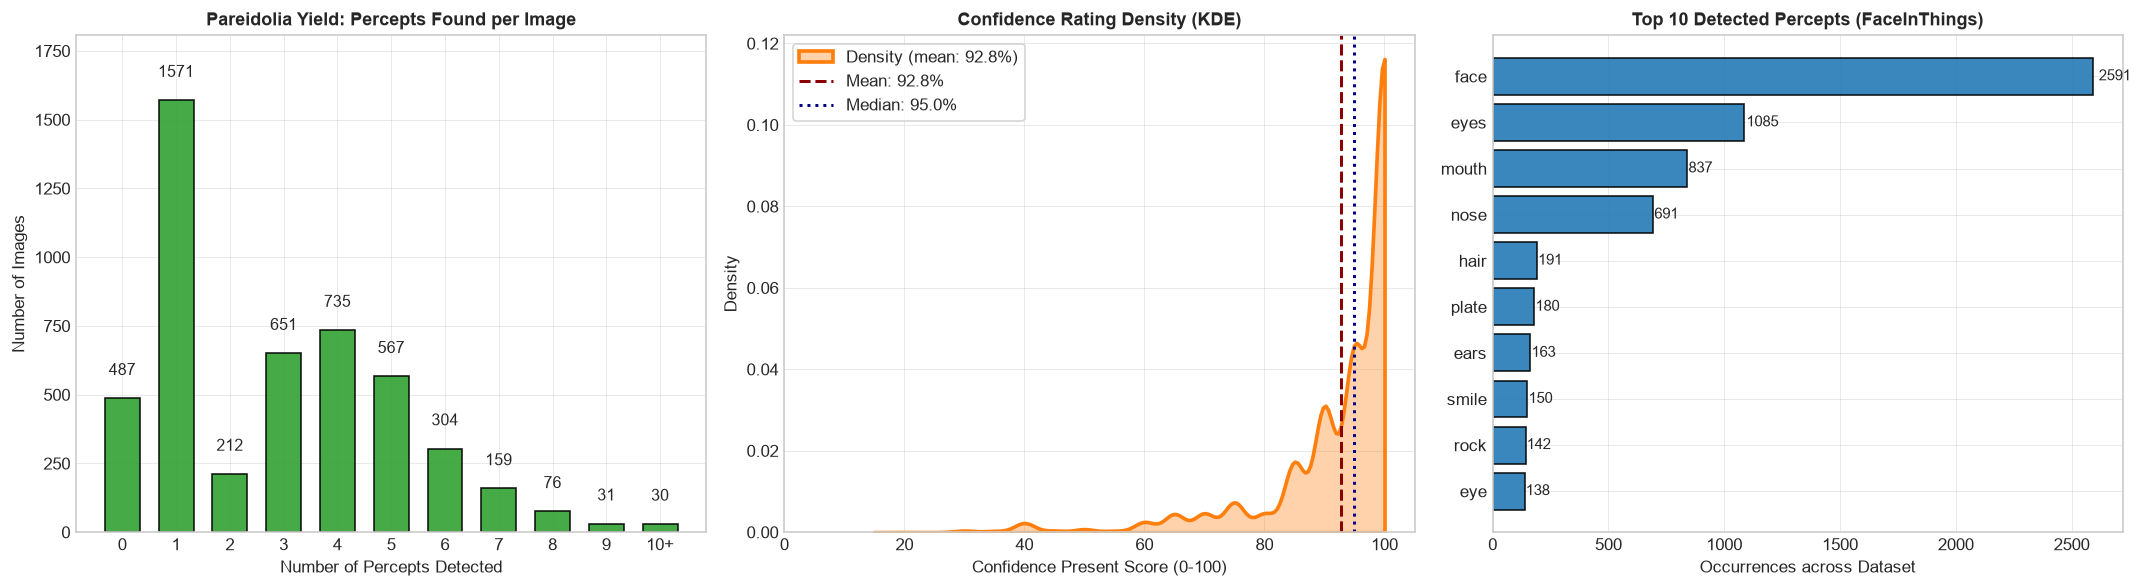

In [40]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Gemma3-26b"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_info(row):
    parsed = extract_image_parsed(row)
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, confs, mean_conf

df_main['extracted_info'] = df_main.apply(extract_percept_info, axis=1)
df_main['percept_labels'] = [x[0] for x in df_main['extracted_info']]
df_main['confidence_list'] = [x[1] for x in df_main['extracted_info']]
df_main['mean_confidence'] = [x[2] for x in df_main['extracted_info']]
df_main['percept_count'] = df_main['percept_labels'].apply(len)
df_main['has_percept'] = df_main['percept_count'] > 0

all_labels = [lbl for labels in df_main['percept_labels'] for lbl in labels]
all_confs = [c for clist in df_main['confidence_list'] for c in clist]
label_counts = Counter(all_labels)

total_images = len(df_main)
detected_images = df_main['has_percept'].sum()
detection_rate = (detected_images / total_images) * 100 if total_images > 0 else 0

print("=" * 75)
print(f"PERCEPTION PROFILE: {MODEL_NAME} ({DATASET_NAME} @ Temp 1.0)")
print("=" * 75)
print(f"Total Evaluated Stimuli       : {total_images}")
print(f"Pareidolia Detection Rate     : {detection_rate:.2f}% ({detected_images}/{total_images} images)")
print(f"Total Percepts Discovered     : {len(all_labels):,}")
print(f"Unique Distinct Labels        : {len(label_counts):,}")
print(f"Mean Percepts per Stimulus    : {df_main['percept_count'].mean():.2f} (std: {df_main['percept_count'].std():.2f})")
if all_confs:
    print(f"Mean Percept Confidence       : {np.mean(all_confs):.2f}% (median: {np.median(all_confs):.2f}%)")
print("-" * 75)

MAX_BINS = 10
def bin_counts(val):
    if val >= MAX_BINS:
        return f"{MAX_BINS}+"
    return str(val)

df_main['percept_binned'] = df_main['percept_count'].apply(bin_counts)
bin_labels = [str(i) for i in range(MAX_BINS)] + [f"{MAX_BINS}+"]
binned_series = df_main['percept_binned'].value_counts().reindex(bin_labels, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Panel 1: Percept Yield (Green)
bars = axes[0].bar(binned_series.index, binned_series.values, color='#2ca02c', edgecolor='black', alpha=0.88, width=0.65)
axes[0].set_title("Pareidolia Yield: Percepts Found per Image", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Number of Percepts Detected", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2.0, h + max(5, total_images * 0.015), f"{h}", ha='center', va='bottom', fontsize=9.5)
axes[0].set_ylim(0, max(binned_series.values) * 1.15)

# Panel 2: Distribution of Reported Confidence (Orange KDE)
if all_confs:
    sns.kdeplot(
        all_confs,
        ax=axes[1],
        color='#ff7f0e',
        linewidth=2.2,
        fill=True,
        alpha=0.35,
        clip=(0, 100),
        label=f"Density (mean: {np.mean(all_confs):.1f}%)"
    )
    axes[1].axvline(np.mean(all_confs), color='darkred', linestyle='--', linewidth=1.8, label=f"Mean: {np.mean(all_confs):.1f}%")
    axes[1].axvline(np.median(all_confs), color='darkblue', linestyle=':', linewidth=1.8, label=f"Median: {np.median(all_confs):.1f}%")
axes[1].set_title("Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Confidence Present Score (0-100)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].set_xlim(0, 105)
axes[1].legend(frameon=True)

# Panel 3: Top 10 Detected Percepts (Blue)
top_10 = pd.DataFrame(label_counts.most_common(10), columns=['Label', 'Count'])
axes[2].barh(top_10['Label'][::-1], top_10['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.88)
axes[2].set_title("Top 10 Detected Percepts (FaceInThings)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Occurrences across Dataset", fontsize=10)
for idx, row in enumerate(top_10.iloc[::-1].itertuples()):
    axes[2].text(row.Count + max(5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [41]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "GPT-5.4"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

main_file = RESULTS_DIR / "main_results.jsonl"
base_file = RESULTS_DIR / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def get_percept_labels(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        return [str(p.get('label', '')).lower().strip() for p in parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        confs = []
        for p in parsed['percepts']:
            if isinstance(p, dict):
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
        if confs:
            return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['parsed_stimulus'] = df_main.apply(extract_image_parsed, axis=1)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['parsed_stimulus'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['parsed_stimulus'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp:
        return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

print("=" * 75)
print(f"VOCABULARY ANALYSIS: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 75)

all_primed_words = [w for wlist in df_main['dat_words'] for w in wlist]
print("\n1. OVERALL VOCABULARY SIZE:")
print(f"  - Total Tokens Produced : {len(all_primed_words):,}")
print(f"  - Unique Vocabulary Size: {len(set(all_primed_words)):,}")
base_vocab_count = len(set([w for ws in df_base['dat_words'] for w in ws])) if not df_base.empty else 0
print(f"  - Baseline Distinct Words: {base_vocab_count:,}")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())
print("=" * 75)

VOCABULARY ANALYSIS: GPT-5.4 (FaceInThings)

1. OVERALL VOCABULARY SIZE:
  - Total Tokens Produced : 45,680
  - Unique Vocabulary Size: 204
  - Baseline Distinct Words: 10

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 1.0: 88.66%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words  ttr  repetition_rate  novel_word_prop  entropy
temperature                                                             
1.0                 10.0  1.0              0.0           0.6852   2.3026


PERCEPTION PROFILE: GPT-5.4 (FaceInThings @ Temp 1.0)
Total Evaluated Stimuli       : 4568
Pareidolia Detection Rate     : 99.98% (4567/4568 images)
Total Percepts Discovered     : 14,939
Unique Distinct Labels        : 1,090
Mean Percepts per Stimulus    : 3.27 (std: 1.85)
Mean Percept Confidence       : 88.86% (median: 94.00%)
---------------------------------------------------------------------------


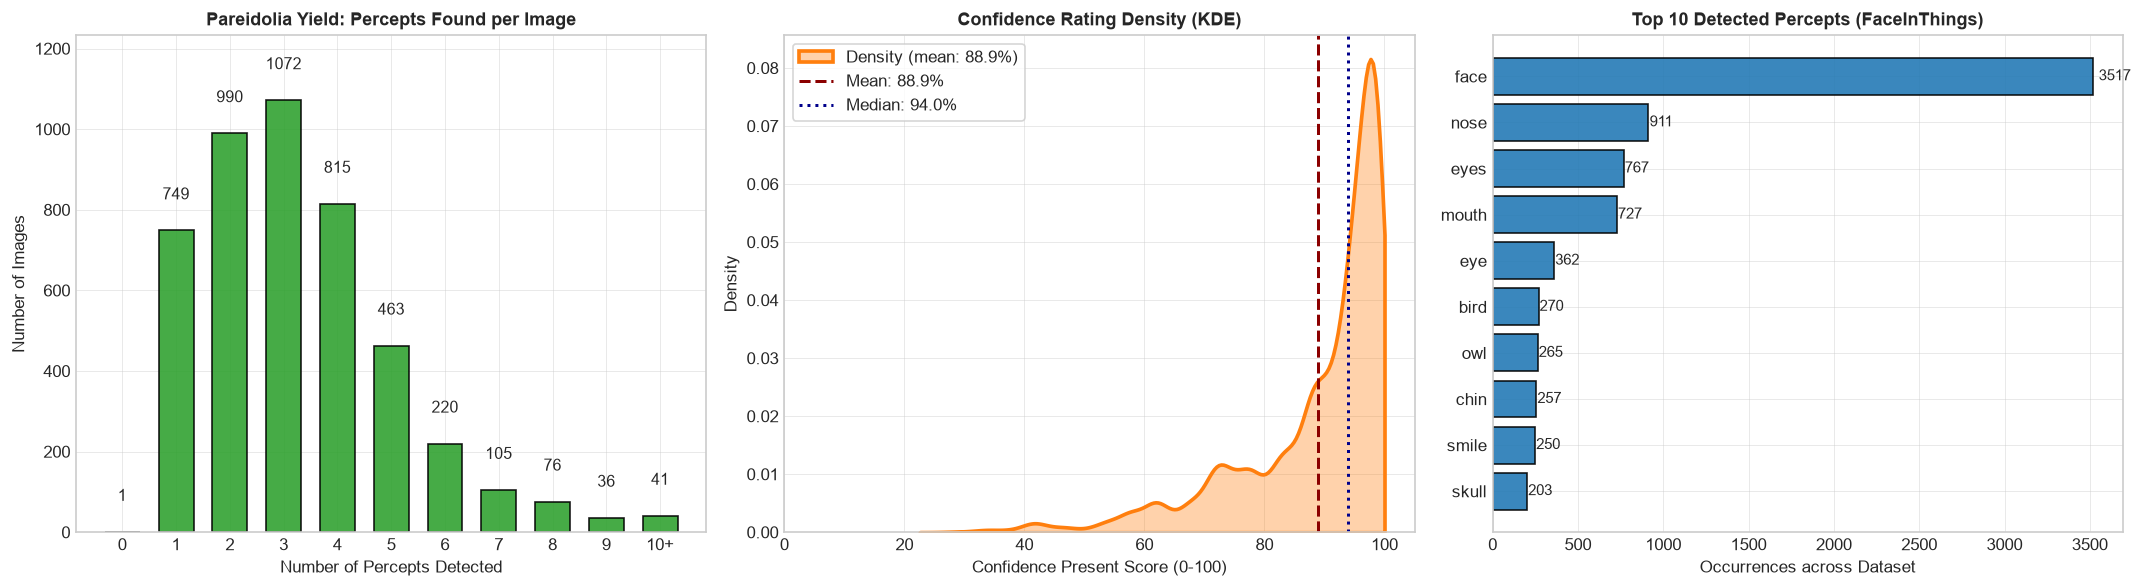

In [42]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "GPT-5.4"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_info(row):
    parsed = extract_image_parsed(row)
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, confs, mean_conf

df_main['extracted_info'] = df_main.apply(extract_percept_info, axis=1)
df_main['percept_labels'] = [x[0] for x in df_main['extracted_info']]
df_main['confidence_list'] = [x[1] for x in df_main['extracted_info']]
df_main['mean_confidence'] = [x[2] for x in df_main['extracted_info']]
df_main['percept_count'] = df_main['percept_labels'].apply(len)
df_main['has_percept'] = df_main['percept_count'] > 0

all_labels = [lbl for labels in df_main['percept_labels'] for lbl in labels]
all_confs = [c for clist in df_main['confidence_list'] for c in clist]
label_counts = Counter(all_labels)

total_images = len(df_main)
detected_images = df_main['has_percept'].sum()
detection_rate = (detected_images / total_images) * 100 if total_images > 0 else 0

print("=" * 75)
print(f"PERCEPTION PROFILE: {MODEL_NAME} ({DATASET_NAME} @ Temp 1.0)")
print("=" * 75)
print(f"Total Evaluated Stimuli       : {total_images}")
print(f"Pareidolia Detection Rate     : {detection_rate:.2f}% ({detected_images}/{total_images} images)")
print(f"Total Percepts Discovered     : {len(all_labels):,}")
print(f"Unique Distinct Labels        : {len(label_counts):,}")
print(f"Mean Percepts per Stimulus    : {df_main['percept_count'].mean():.2f} (std: {df_main['percept_count'].std():.2f})")
if all_confs:
    print(f"Mean Percept Confidence       : {np.mean(all_confs):.2f}% (median: {np.median(all_confs):.2f}%)")
print("-" * 75)

MAX_BINS = 10
def bin_counts(val):
    if val >= MAX_BINS:
        return f"{MAX_BINS}+"
    return str(val)

df_main['percept_binned'] = df_main['percept_count'].apply(bin_counts)
bin_labels = [str(i) for i in range(MAX_BINS)] + [f"{MAX_BINS}+"]
binned_series = df_main['percept_binned'].value_counts().reindex(bin_labels, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Panel 1: Percept Yield (Green)
bars = axes[0].bar(binned_series.index, binned_series.values, color='#2ca02c', edgecolor='black', alpha=0.88, width=0.65)
axes[0].set_title("Pareidolia Yield: Percepts Found per Image", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Number of Percepts Detected", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2.0, h + max(5, total_images * 0.015), f"{h}", ha='center', va='bottom', fontsize=9.5)
axes[0].set_ylim(0, max(binned_series.values) * 1.15)

# Panel 2: Distribution of Reported Confidence (Orange KDE)
if all_confs:
    sns.kdeplot(
        all_confs,
        ax=axes[1],
        color='#ff7f0e',
        linewidth=2.2,
        fill=True,
        alpha=0.35,
        clip=(0, 100),
        label=f"Density (mean: {np.mean(all_confs):.1f}%)"
    )
    axes[1].axvline(np.mean(all_confs), color='darkred', linestyle='--', linewidth=1.8, label=f"Mean: {np.mean(all_confs):.1f}%")
    axes[1].axvline(np.median(all_confs), color='darkblue', linestyle=':', linewidth=1.8, label=f"Median: {np.median(all_confs):.1f}%")
axes[1].set_title("Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Confidence Present Score (0-100)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].set_xlim(0, 105)
axes[1].legend(frameon=True)

# Panel 3: Top 10 Detected Percepts (Blue)
top_10 = pd.DataFrame(label_counts.most_common(10), columns=['Label', 'Count'])
axes[2].barh(top_10['Label'][::-1], top_10['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.88)
axes[2].set_title("Top 10 Detected Percepts (FaceInThings)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Occurrences across Dataset", fontsize=10)
for idx, row in enumerate(top_10.iloc[::-1].itertuples()):
    axes[2].text(row.Count + max(5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Mistral-Small-4"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

main_file = RESULTS_DIR / "main_results.jsonl"
base_file = RESULTS_DIR / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict) and 'words' in dat_parsed:
        return [str(w).lower().strip() for w in dat_parsed['words'] if str(w).strip()]
    return []

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def get_percept_labels(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        return [str(p.get('label', '')).lower().strip() for p in parsed['percepts'] if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        confs = []
        for p in parsed['percepts']:
            if isinstance(p, dict):
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
        if confs:
            return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['parsed_stimulus'] = df_main.apply(extract_image_parsed, axis=1)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['parsed_stimulus'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['parsed_stimulus'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp:
        return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

print("=" * 75)
print(f"VOCABULARY ANALYSIS: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 75)

all_primed_words = [w for wlist in df_main['dat_words'] for w in wlist]
print("\n1. OVERALL VOCABULARY SIZE:")
print(f"  - Total Tokens Produced : {len(all_primed_words):,}")
print(f"  - Unique Vocabulary Size: {len(set(all_primed_words)):,}")
base_vocab_count = len(set([w for ws in df_base['dat_words'] for w in ws])) if not df_base.empty else 0
print(f"  - Baseline Distinct Words: {base_vocab_count:,}")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())
print("=" * 75)

VOCABULARY ANALYSIS: Mistral-Small-4 (FaceInThings)

1. OVERALL VOCABULARY SIZE:
  - Total Tokens Produced : 48,270
  - Unique Vocabulary Size: 2,220
  - Baseline Distinct Words: 9

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 1.0: 87.06%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
1.0                 10.0  0.9994           0.0006           0.8965   2.3017


PERCEPTION PROFILE: Mistral-Small-4 (FaceInThings @ Temp 1.0)
Total Evaluated Stimuli       : 4827
Pareidolia Detection Rate     : 14.71% (710/4827 images)
Total Percepts Discovered     : 2,480
Unique Distinct Labels        : 737
Mean Percepts per Stimulus    : 0.51 (std: 1.39)
Mean Percept Confidence       : 87.56% (median: 90.00%)
---------------------------------------------------------------------------


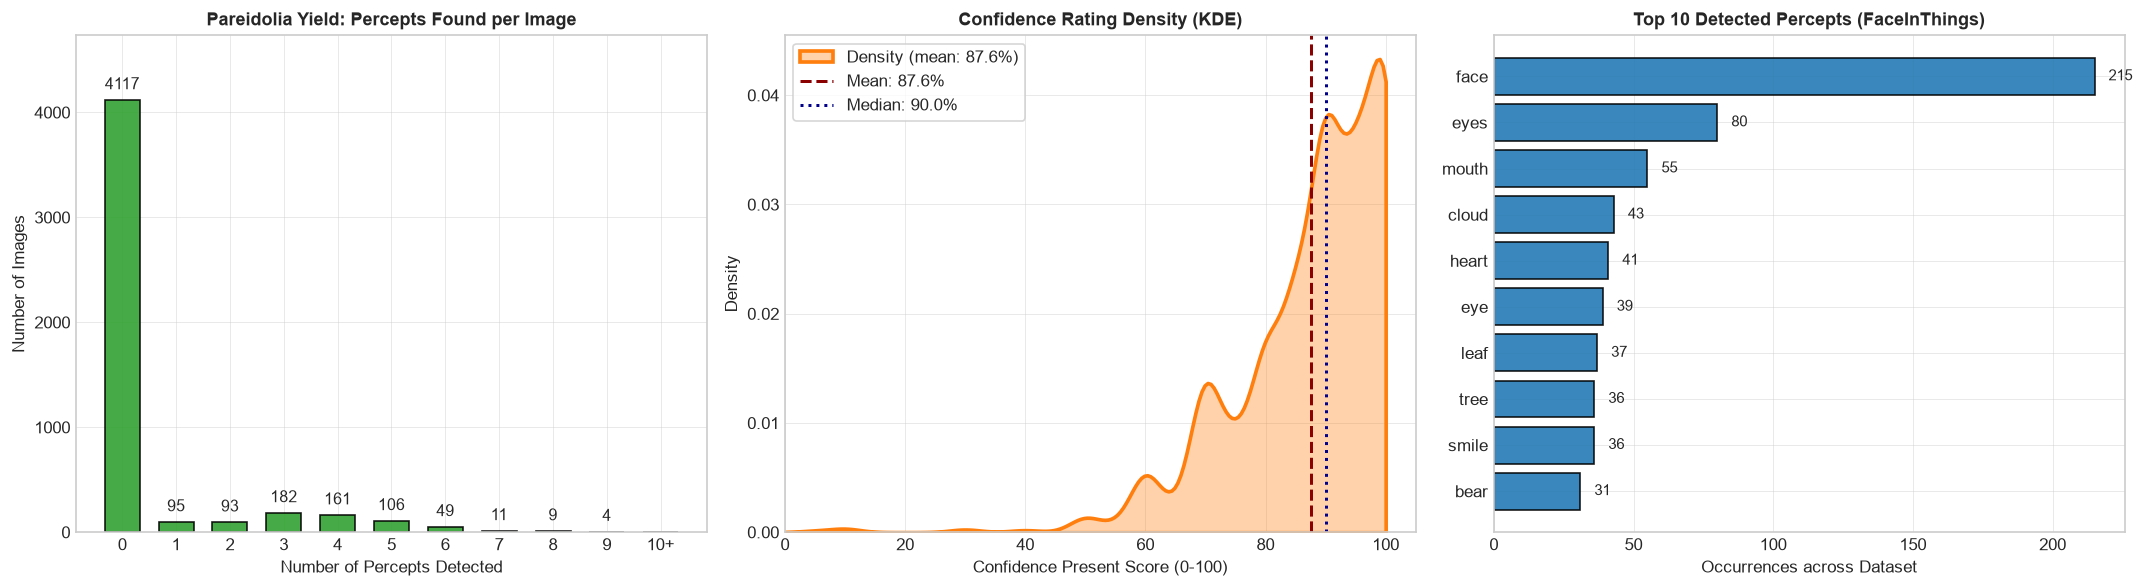

In [44]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Mistral-Small-4"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_info(row):
    parsed = extract_image_parsed(row)
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        for p in parsed['percepts']:
            if isinstance(p, dict):
                lbl = str(p.get('label', '')).lower().strip()
                if lbl:
                    labels.append(lbl)
                c_val = safe_parse_confidence(p.get('confidence_present'))
                if c_val is not None:
                    confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, confs, mean_conf

df_main['extracted_info'] = df_main.apply(extract_percept_info, axis=1)
df_main['percept_labels'] = [x[0] for x in df_main['extracted_info']]
df_main['confidence_list'] = [x[1] for x in df_main['extracted_info']]
df_main['mean_confidence'] = [x[2] for x in df_main['extracted_info']]
df_main['percept_count'] = df_main['percept_labels'].apply(len)
df_main['has_percept'] = df_main['percept_count'] > 0

all_labels = [lbl for labels in df_main['percept_labels'] for lbl in labels]
all_confs = [c for clist in df_main['confidence_list'] for c in clist]
label_counts = Counter(all_labels)

total_images = len(df_main)
detected_images = df_main['has_percept'].sum()
detection_rate = (detected_images / total_images) * 100 if total_images > 0 else 0

print("=" * 75)
print(f"PERCEPTION PROFILE: {MODEL_NAME} ({DATASET_NAME} @ Temp 1.0)")
print("=" * 75)
print(f"Total Evaluated Stimuli       : {total_images}")
print(f"Pareidolia Detection Rate     : {detection_rate:.2f}% ({detected_images}/{total_images} images)")
print(f"Total Percepts Discovered     : {len(all_labels):,}")
print(f"Unique Distinct Labels        : {len(label_counts):,}")
print(f"Mean Percepts per Stimulus    : {df_main['percept_count'].mean():.2f} (std: {df_main['percept_count'].std():.2f})")
if all_confs:
    print(f"Mean Percept Confidence       : {np.mean(all_confs):.2f}% (median: {np.median(all_confs):.2f}%)")
print("-" * 75)

MAX_BINS = 10
def bin_counts(val):
    if val >= MAX_BINS:
        return f"{MAX_BINS}+"
    return str(val)

df_main['percept_binned'] = df_main['percept_count'].apply(bin_counts)
bin_labels = [str(i) for i in range(MAX_BINS)] + [f"{MAX_BINS}+"]
binned_series = df_main['percept_binned'].value_counts().reindex(bin_labels, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Panel 1: Percept Yield (Green)
bars = axes[0].bar(binned_series.index, binned_series.values, color='#2ca02c', edgecolor='black', alpha=0.88, width=0.65)
axes[0].set_title("Pareidolia Yield: Percepts Found per Image", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Number of Percepts Detected", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2.0, h + max(5, total_images * 0.015), f"{h}", ha='center', va='bottom', fontsize=9.5)
axes[0].set_ylim(0, max(binned_series.values) * 1.15)

# Panel 2: Distribution of Reported Confidence (Orange KDE)
if all_confs:
    sns.kdeplot(
        all_confs,
        ax=axes[1],
        color='#ff7f0e',
        linewidth=2.2,
        fill=True,
        alpha=0.35,
        clip=(0, 100),
        label=f"Density (mean: {np.mean(all_confs):.1f}%)"
    )
    axes[1].axvline(np.mean(all_confs), color='darkred', linestyle='--', linewidth=1.8, label=f"Mean: {np.mean(all_confs):.1f}%")
    axes[1].axvline(np.median(all_confs), color='darkblue', linestyle=':', linewidth=1.8, label=f"Median: {np.median(all_confs):.1f}%")
axes[1].set_title("Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Confidence Present Score (0-100)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].set_xlim(0, 105)
axes[1].legend(frameon=True)

# Panel 3: Top 10 Detected Percepts (Blue)
top_10 = pd.DataFrame(label_counts.most_common(10), columns=['Label', 'Count'])
axes[2].barh(top_10['Label'][::-1], top_10['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.88)
axes[2].set_title("Top 10 Detected Percepts (FaceInThings)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Occurrences across Dataset", fontsize=10)
for idx, row in enumerate(top_10.iloc[::-1].itertuples()):
    axes[2].text(row.Count + max(5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [46]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

MODEL_NAME = "Qwen3.5-9B"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME

main_file = RESULTS_DIR / "main_results.jsonl"
base_file = RESULTS_DIR / "dat_baseline_results.jsonl"

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

base_records = []
if base_file.exists():
    with open(base_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    base_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)
df_base = pd.DataFrame(base_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict):
        words = dat_parsed.get('words')
        if isinstance(words, list):
            return [str(w).lower().strip() for w in words if w is not None and str(w).strip()]
    return []

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def get_percept_labels(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        percepts = parsed.get('percepts')
        if isinstance(percepts, list):
            return [str(p.get('label', '')).lower().strip() for p in percepts if isinstance(p, dict) and p.get('label')]
    return []

def get_mean_confidence(parsed):
    if isinstance(parsed, dict) and 'percepts' in parsed:
        percepts = parsed.get('percepts')
        if isinstance(percepts, list):
            confs = []
            for p in percepts:
                if isinstance(p, dict):
                    c_val = safe_parse_confidence(p.get('confidence_present'))
                    if c_val is not None:
                        confs.append(c_val)
            if confs:
                return float(np.mean(confs))
    return np.nan

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

df_main['parsed_stimulus'] = df_main.apply(extract_image_parsed, axis=1)
df_main['dat_words'] = df_main['dat_parsed'].apply(get_dat_words)
df_main['percept_labels'] = df_main['parsed_stimulus'].apply(get_percept_labels)
df_main['mean_confidence'] = df_main['parsed_stimulus'].apply(get_mean_confidence)

df_main['total_words'] = df_main['dat_words'].apply(len)
df_main['unique_words'] = df_main['dat_words'].apply(lambda x: len(set(x)))
df_main['ttr'] = df_main['dat_words'].apply(calc_ttr)
df_main['repetition_rate'] = 1.0 - df_main['ttr']
df_main['entropy'] = df_main['dat_words'].apply(calc_entropy)

df_base['dat_words'] = df_base['dat_parsed'].apply(get_dat_words)
baseline_vocab_by_temp = {}
if not df_base.empty and 'temperature' in df_base.columns:
    for temp, group in df_base.groupby('temperature'):
        baseline_vocab_by_temp[temp] = set([w for words in group['dat_words'] for w in words])

def calc_novel_ratio(row):
    temp = row.get('temperature')
    words = row.get('dat_words', [])
    if not words or temp not in baseline_vocab_by_temp:
        return 0.0
    base_vocab = baseline_vocab_by_temp[temp]
    novel_words = [w for w in words if w not in base_vocab]
    return len(novel_words) / len(words)

df_main['novel_word_prop'] = df_main.apply(calc_novel_ratio, axis=1)

print("=" * 75)
print(f"VOCABULARY ANALYSIS: {MODEL_NAME} ({DATASET_NAME})")
print("=" * 75)

all_primed_words = [w for wlist in df_main['dat_words'] for w in wlist]
print("\n1. OVERALL VOCABULARY SIZE:")
print(f"  - Total Tokens Produced : {len(all_primed_words):,}")
print(f"  - Unique Vocabulary Size: {len(set(all_primed_words)):,}")
base_vocab_count = len(set([w for ws in df_base['dat_words'] for w in ws])) if not df_base.empty else 0
print(f"  - Baseline Distinct Words: {base_vocab_count:,}")

print("\n2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:")
mean_conf = df_main.groupby('temperature')['mean_confidence'].mean()
for t, val in mean_conf.items():
    print(f"  - Temp {t}: {val:.2f}%")

print("\n3. WORD DIVERSITY METRICS (Averaged across runs):")
div_metrics = ['total_words', 'ttr', 'repetition_rate', 'novel_word_prop', 'entropy']
diversity_summary = df_main.groupby('temperature')[div_metrics].mean()
print(diversity_summary.round(4).to_string())
print("=" * 75)

VOCABULARY ANALYSIS: Qwen3.5-9B (FaceInThings)

1. OVERALL VOCABULARY SIZE:
  - Total Tokens Produced : 27,250
  - Unique Vocabulary Size: 2,171
  - Baseline Distinct Words: 10

2. MEAN CONFIDENCE LEVELS BY TEMPERATURE:
  - Temp 1.0: 93.36%

3. WORD DIVERSITY METRICS (Averaged across runs):
             total_words     ttr  repetition_rate  novel_word_prop  entropy
temperature                                                                
1.0               9.9019  0.9785           0.0215           0.8934   2.2598


PERCEPTION PROFILE: Qwen3.5-9B (FaceInThings @ Temp 1.0)
Total Evaluated Stimuli       : 2752
Pareidolia Detection Rate     : 87.39% (2405/2752 images)
Total Percepts Discovered     : 8,426
Unique Distinct Labels        : 1,754
Mean Percepts per Stimulus    : 3.06 (std: 2.84)
Mean Percept Confidence       : 93.28% (median: 100.00%)
---------------------------------------------------------------------------


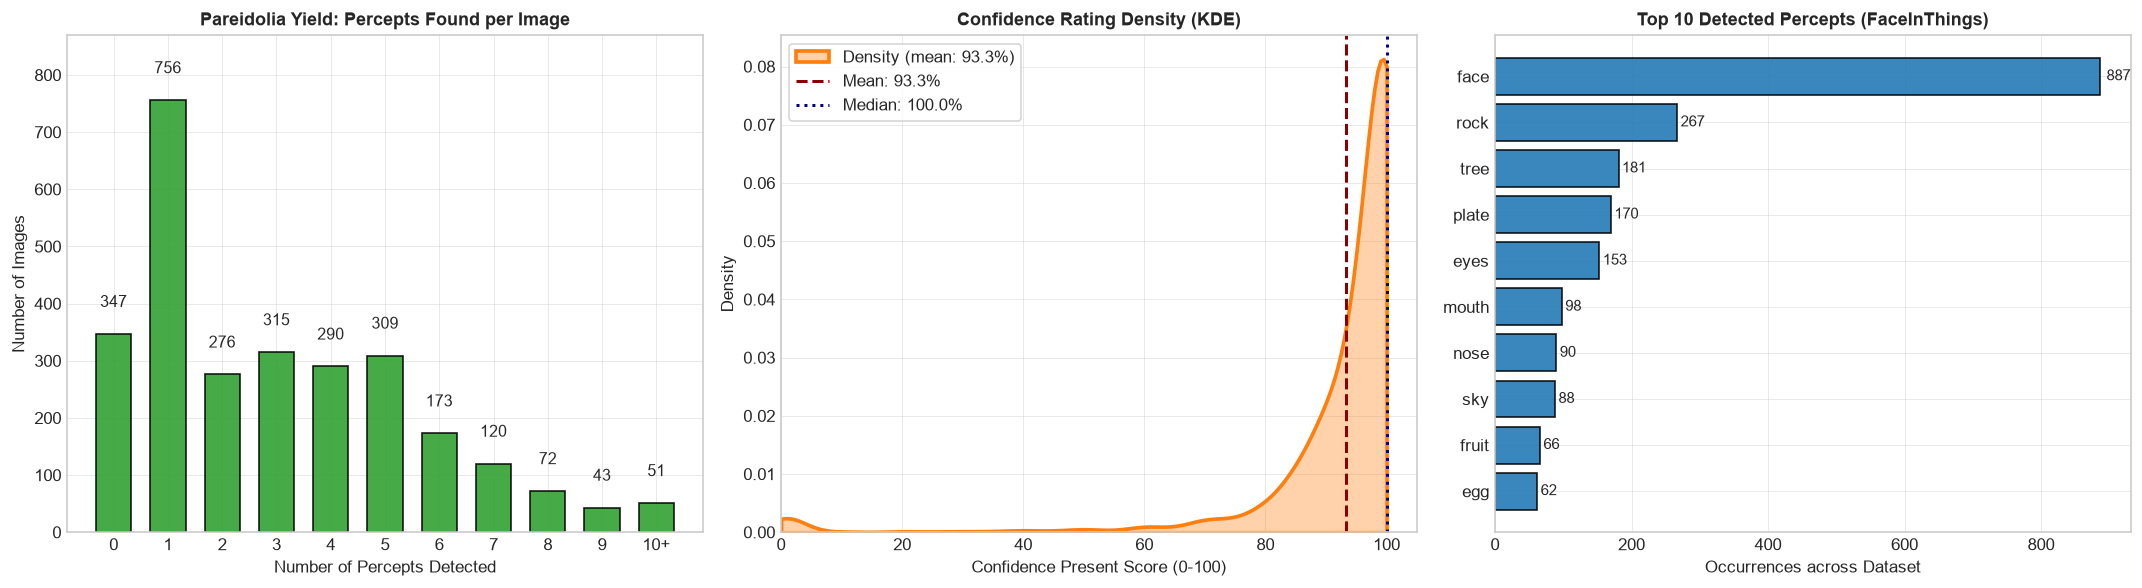

In [49]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

MODEL_NAME = "Qwen3.5-9B"
DATASET_NAME = "FaceInThings"
RESULTS_DIR = Path("results") / DATASET_NAME / MODEL_NAME
main_file = RESULTS_DIR / "main_results.jsonl"

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

main_records = []
if main_file.exists():
    with open(main_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    main_records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

df_main = pd.DataFrame(main_records)

if df_main.empty:
    raise ValueError(f"No records found in {main_file}")

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_percept_info(row):
    parsed = extract_image_parsed(row)
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        percepts = parsed.get('percepts')
        if isinstance(percepts, list):
            for p in percepts:
                if isinstance(p, dict):
                    lbl = str(p.get('label', '')).lower().strip()
                    if lbl:
                        labels.append(lbl)
                    c_val = safe_parse_confidence(p.get('confidence_present'))
                    if c_val is not None:
                        confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, confs, mean_conf

df_main['extracted_info'] = df_main.apply(extract_percept_info, axis=1)
df_main['percept_labels'] = [x[0] for x in df_main['extracted_info']]
df_main['confidence_list'] = [x[1] for x in df_main['extracted_info']]
df_main['mean_confidence'] = [x[2] for x in df_main['extracted_info']]
df_main['percept_count'] = df_main['percept_labels'].apply(len)
df_main['has_percept'] = df_main['percept_count'] > 0

all_labels = [lbl for labels in df_main['percept_labels'] for lbl in labels]
all_confs = [c for clist in df_main['confidence_list'] for c in clist]
label_counts = Counter(all_labels)

total_images = len(df_main)
detected_images = df_main['has_percept'].sum()
detection_rate = (detected_images / total_images) * 100 if total_images > 0 else 0

print("=" * 75)
print(f"PERCEPTION PROFILE: {MODEL_NAME} ({DATASET_NAME} @ Temp 1.0)")
print("=" * 75)
print(f"Total Evaluated Stimuli       : {total_images}")
print(f"Pareidolia Detection Rate     : {detection_rate:.2f}% ({detected_images}/{total_images} images)")
print(f"Total Percepts Discovered     : {len(all_labels):,}")
print(f"Unique Distinct Labels        : {len(label_counts):,}")
print(f"Mean Percepts per Stimulus    : {df_main['percept_count'].mean():.2f} (std: {df_main['percept_count'].std():.2f})")
if all_confs:
    print(f"Mean Percept Confidence       : {np.mean(all_confs):.2f}% (median: {np.median(all_confs):.2f}%)")
print("-" * 75)

MAX_BINS = 10
def bin_counts(val):
    if val >= MAX_BINS:
        return f"{MAX_BINS}+"
    return str(val)

df_main['percept_binned'] = df_main['percept_count'].apply(bin_counts)
bin_labels = [str(i) for i in range(MAX_BINS)] + [f"{MAX_BINS}+"]
binned_series = df_main['percept_binned'].value_counts().reindex(bin_labels, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# Panel 1: Percept Yield (Green)
bars = axes[0].bar(binned_series.index, binned_series.values, color='#2ca02c', edgecolor='black', alpha=0.88, width=0.65)
axes[0].set_title("Pareidolia Yield: Percepts Found per Image", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Number of Percepts Detected", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=10)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2.0, h + max(5, total_images * 0.015), f"{h}", ha='center', va='bottom', fontsize=9.5)
axes[0].set_ylim(0, max(binned_series.values) * 1.15)

# Panel 2: Distribution of Reported Confidence (Orange KDE)
if all_confs:
    sns.kdeplot(
        all_confs,
        ax=axes[1],
        color='#ff7f0e',
        linewidth=2.2,
        fill=True,
        alpha=0.35,
        clip=(0, 100),
        label=f"Density (mean: {np.mean(all_confs):.1f}%)"
    )
    axes[1].axvline(np.mean(all_confs), color='darkred', linestyle='--', linewidth=1.8, label=f"Mean: {np.mean(all_confs):.1f}%")
    axes[1].axvline(np.median(all_confs), color='darkblue', linestyle=':', linewidth=1.8, label=f"Median: {np.median(all_confs):.1f}%")
axes[1].set_title("Confidence Rating Density (KDE)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Confidence Present Score (0-100)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].set_xlim(0, 105)
axes[1].legend(frameon=True)

# Panel 3: Top 10 Detected Percepts (Blue)
top_10 = pd.DataFrame(label_counts.most_common(10), columns=['Label', 'Count'])
axes[2].barh(top_10['Label'][::-1], top_10['Count'][::-1], color='#1f77b4', edgecolor='black', alpha=0.88)
axes[2].set_title("Top 10 Detected Percepts (FaceInThings)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Occurrences across Dataset", fontsize=10)
for idx, row in enumerate(top_10.iloc[::-1].itertuples()):
    axes[2].text(row.Count + max(5, row.Count * 0.01), idx, f"{row.Count}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [50]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

RESULTS_DIR = Path("results")

MODELS = [
    "Gemini-3.1-Pro",
    "Claude-Opus-4-7",
    "Gemma3-26b",
    "GPT-5.4",
    "Mistral-Small-4",
    "Qwen3.5-9B"
]

DATASETS = ["Fractals", "FaceInThings"]

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def extract_image_parsed(row):
    return row.get('image_parsed') or row.get('fractal_parsed') or {}

def extract_labels_and_confs(parsed):
    labels, confs = [], []
    if isinstance(parsed, dict):
        percepts = parsed.get('percepts')
        if isinstance(percepts, list):
            for p in percepts:
                if isinstance(p, dict):
                    lbl = str(p.get('label', '')).lower().strip()
                    if lbl:
                        labels.append(lbl)
                    c_val = safe_parse_confidence(p.get('confidence_present'))
                    if c_val is not None:
                        confs.append(c_val)
    return labels, confs

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict):
        words = dat_parsed.get('words')
        if isinstance(words, list):
            return [str(w).lower().strip() for w in words if w is not None and str(w).strip()]
    return []

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

overview_rows = []

for dataset in DATASETS:
    for model in MODELS:
        # Resolve path hierarchy: results/DATASET/MODEL or results/MODEL
        cand_paths = [
            RESULTS_DIR / dataset / model / "main_results.jsonl",
            RESULTS_DIR / model / "main_results.jsonl" if dataset == "Fractals" else None
        ]
        main_file = next((p for p in cand_paths if p and p.exists()), None)

        if not main_file:
            continue

        records = []
        with open(main_file, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass

        if not records:
            continue

        df = pd.DataFrame(records)
        df['parsed'] = df.apply(extract_image_parsed, axis=1)

        labels_confs = df['parsed'].apply(extract_labels_and_confs)
        df['labels'] = [x[0] for x in labels_confs]
        df['confs'] = [x[1] for x in labels_confs]
        df['percept_count'] = df['labels'].apply(len)
        df['has_percept'] = df['percept_count'] > 0

        all_labels = [l for sub in df['labels'] for l in sub]
        all_confs = [c for sub in df['confs'] for c in sub]

        # DAT Metrics
        df['dat_words'] = df['dat_parsed'].apply(get_dat_words) if 'dat_parsed' in df.columns else [[]] * len(df)
        df['ttr'] = df['dat_words'].apply(calc_ttr)
        df['entropy'] = df['dat_words'].apply(calc_entropy)
        all_dat_words = [w for sub in df['dat_words'] for w in sub]

        total_eval = len(df)
        detection_rate = (df['has_percept'].sum() / total_eval) * 100 if total_eval > 0 else 0.0

        overview_rows.append({
            'Dataset': dataset,
            'Model': model,
            'Total Runs': total_eval,
            'Detection Rate (%)': round(detection_rate, 2),
            'Mean Percepts / Image': round(df['percept_count'].mean(), 2),
            'Total Percepts Found': len(all_labels),
            'Unique Labels': len(set(all_labels)),
            'Mean Confidence (%)': round(np.mean(all_confs), 2) if all_confs else np.nan,
            'DAT Words Produced': len(all_dat_words),
            'DAT Vocab Size': len(set(all_dat_words)),
            'Mean TTR': round(df['ttr'].mean(), 4) if all_dat_words else np.nan,
            'Mean Entropy': round(df['entropy'].mean(), 4) if all_dat_words else np.nan
        })

df_overview = pd.DataFrame(overview_rows)

print("=" * 110)
print("BENCHMARK CROSS-MODEL OVERVIEW SUMMARY")
print("=" * 110)
print(df_overview.to_string(index=False))
print("=" * 110)

# Export consolidated overview to CSV
csv_out = RESULTS_DIR / "cross_model_benchmark_overview.csv"
df_overview.to_csv(csv_out, index=False)
print(f"\nSummary table exported to: {csv_out.resolve()}")

BENCHMARK CROSS-MODEL OVERVIEW SUMMARY
     Dataset           Model  Total Runs  Detection Rate (%)  Mean Percepts / Image  Total Percepts Found  Unique Labels  Mean Confidence (%)  DAT Words Produced  DAT Vocab Size  Mean TTR  Mean Entropy
FaceInThings  Gemini-3.1-Pro        4483               99.82                   4.92                 22051           1630                86.00               44820             829    0.9998        2.3021
FaceInThings Claude-Opus-4-7        2052               99.95                   6.86                 14079           1676                80.18               20520             425    1.0000        2.3026
FaceInThings      Gemma3-26b        4823               89.90                   2.88                 13893           1262                92.80               48200             257    0.9994        2.3011
FaceInThings         GPT-5.4        4568               99.98                   3.27                 14939           1090                88.86            

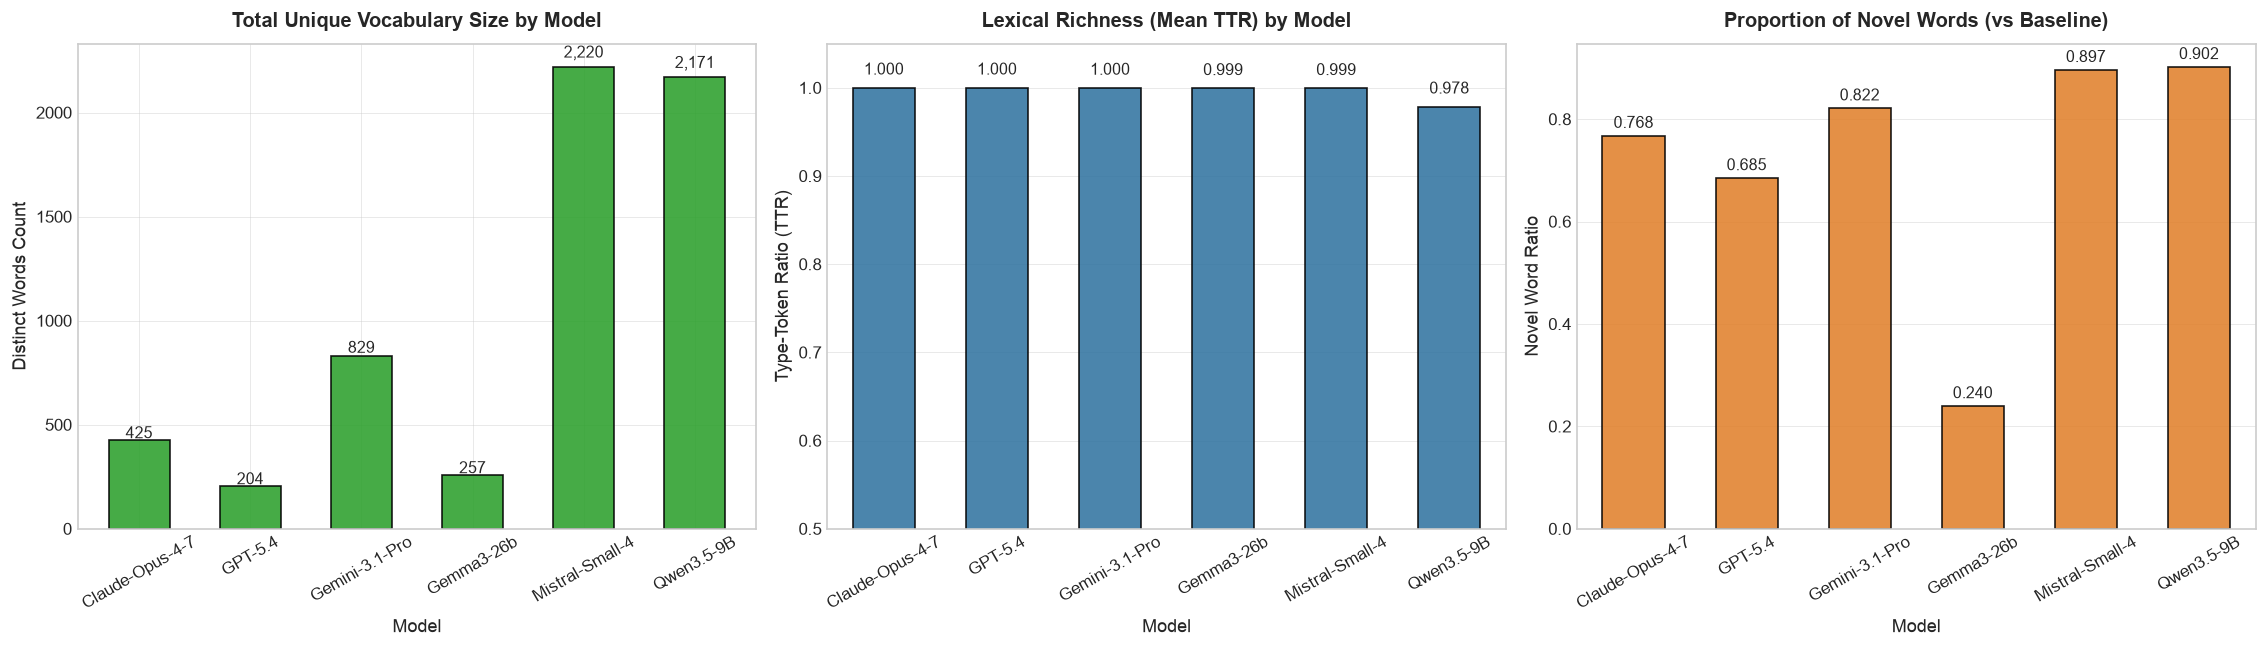

In [51]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy.stats import entropy

RESULTS_DIR = Path("results") / "FaceInThings"
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def get_dat_words(dat_parsed):
    if isinstance(dat_parsed, dict):
        words = dat_parsed.get('words')
        if isinstance(words, list):
            return [str(w).lower().strip() for w in words if w is not None and str(w).strip()]
    return []

def calc_ttr(words):
    return len(set(words)) / len(words) if words else 0.0

def calc_entropy(words):
    if not words:
        return 0.0
    counts = list(Counter(words).values())
    probs = np.array(counts) / sum(counts)
    return entropy(probs)

all_main_dfs = []
all_base_dfs = []

# Scan all model directories inside results/FaceInThings/
for model_dir in sorted(RESULTS_DIR.iterdir()):
    if model_dir.is_dir():
        model_name = model_dir.name
        main_path = model_dir / "main_results.jsonl"
        base_path = model_dir / "dat_baseline_results.jsonl"

        main_records = []
        if main_path.exists():
            with open(main_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        try:
                            item = json.loads(line)
                            item['model'] = model_name
                            main_records.append(item)
                        except json.JSONDecodeError:
                            pass
        if main_records:
            all_main_dfs.append(pd.DataFrame(main_records))

        base_records = []
        if base_path.exists():
            with open(base_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        try:
                            item = json.loads(line)
                            item['model'] = model_name
                            base_records.append(item)
                        except json.JSONDecodeError:
                            pass
        if base_records:
            all_base_dfs.append(pd.DataFrame(base_records))

if not all_main_dfs:
    raise FileNotFoundError("No result files found in results/FaceInThings/")

df_all = pd.concat(all_main_dfs, ignore_index=True)
df_base_all = pd.concat(all_base_dfs, ignore_index=True) if all_base_dfs else pd.DataFrame()

# Preprocessing metrics
df_all['dat_words'] = df_all['dat_parsed'].apply(get_dat_words)
df_all['total_words'] = df_all['dat_words'].apply(len)
df_all['unique_words'] = df_all['dat_words'].apply(lambda x: len(set(x)))
df_all['ttr'] = df_all['dat_words'].apply(calc_ttr)
df_all['entropy'] = df_all['dat_words'].apply(calc_entropy)

# Baseline vocabulary mapping
baseline_vocab_map = {}
if not df_base_all.empty:
    df_base_all['dat_words'] = df_base_all['dat_parsed'].apply(get_dat_words)
    for (m, t), grp in df_base_all.groupby(['model', 'temperature']):
        baseline_vocab_map[(m, t)] = set([w for ws in grp['dat_words'] for w in ws])

def calc_novelty(row):
    key = (row['model'], row.get('temperature', 1.0))
    words = row['dat_words']
    if not words or key not in baseline_vocab_map:
        return np.nan
    base_v = baseline_vocab_map[key]
    novel = [w for w in words if w not in base_v]
    return len(novel) / len(words)

df_all['novel_ratio'] = df_all.apply(calc_novelty, axis=1)

# Summary table for total unique vocabulary per model
vocab_summary = []
for model, grp in df_all.groupby('model'):
    unique_tot = len(set([w for ws in grp['dat_words'] for w in ws]))
    vocab_summary.append({'model': model, 'unique_vocab_size': unique_tot})

df_model_vocab = pd.DataFrame(vocab_summary).set_index('model')

# Plot setup
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), dpi=120)

# Panel 1: Total Unique Vocabulary Size by Model
axes[0].bar(
    df_model_vocab.index,
    df_model_vocab['unique_vocab_size'],
    color='#2ca02c',
    edgecolor='black',
    alpha=0.88,
    width=0.55
)
axes[0].set_title("Total Unique Vocabulary Size by Model", fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel("Distinct Words Count", fontsize=11)
axes[0].set_xlabel("Model", fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for idx, (m, val) in enumerate(df_model_vocab['unique_vocab_size'].items()):
    axes[0].text(idx, val + max(10, val * 0.02), f"{val:,}", ha='center', fontsize=9.5)

# Panel 2: Lexical Richness (Mean TTR) per model
sns.barplot(
    data=df_all,
    x='model',
    y='ttr',
    color='#1f77b4',
    edgecolor='black',
    alpha=0.88,
    ax=axes[1],
    errorbar=None,
    width=0.55
)
axes[1].set_title("Lexical Richness (Mean TTR) by Model", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel("Type-Token Ratio (TTR)", fontsize=11)
axes[1].set_xlabel("Model", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0.5, 1.05)
for idx, val in enumerate(df_all.groupby('model')['ttr'].mean()):
    axes[1].text(idx, val + 0.015, f"{val:.3f}", ha='center', fontsize=9.5)

# Panel 3: Novel word ratio compared to baseline
sns.barplot(
    data=df_all.dropna(subset=['novel_ratio']),
    x='model',
    y='novel_ratio',
    color='#ff7f0e',
    edgecolor='black',
    alpha=0.88,
    ax=axes[2],
    errorbar=None,
    width=0.55
)
axes[2].set_title("Proportion of Novel Words (vs Baseline)", fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel("Novel Word Ratio", fontsize=11)
axes[2].set_xlabel("Model", fontsize=11)
axes[2].tick_params(axis='x', rotation=30)
for idx, val in enumerate(df_all.dropna(subset=['novel_ratio']).groupby('model')['novel_ratio'].mean()):
    axes[2].text(idx, val + 0.015, f"{val:.3f}", ha='center', fontsize=9.5)

plt.tight_layout()
plt.show()

PAREIDOLIA PERCEPTION OVERVIEW (FaceInThings @ Temp 1.0):
                 detection_rate  mean_yield  mean_confidence
model                                                       
Claude-Opus-4-7           99.95        6.86            79.23
GPT-5.4                   99.98        3.27            88.66
Gemini-3.1-Pro            99.82        4.92            89.95
Gemma3-26b                89.90        2.88            88.69
Mistral-Small-4           14.71        0.51            87.06
Qwen3.5-9B                87.39        3.06            93.36


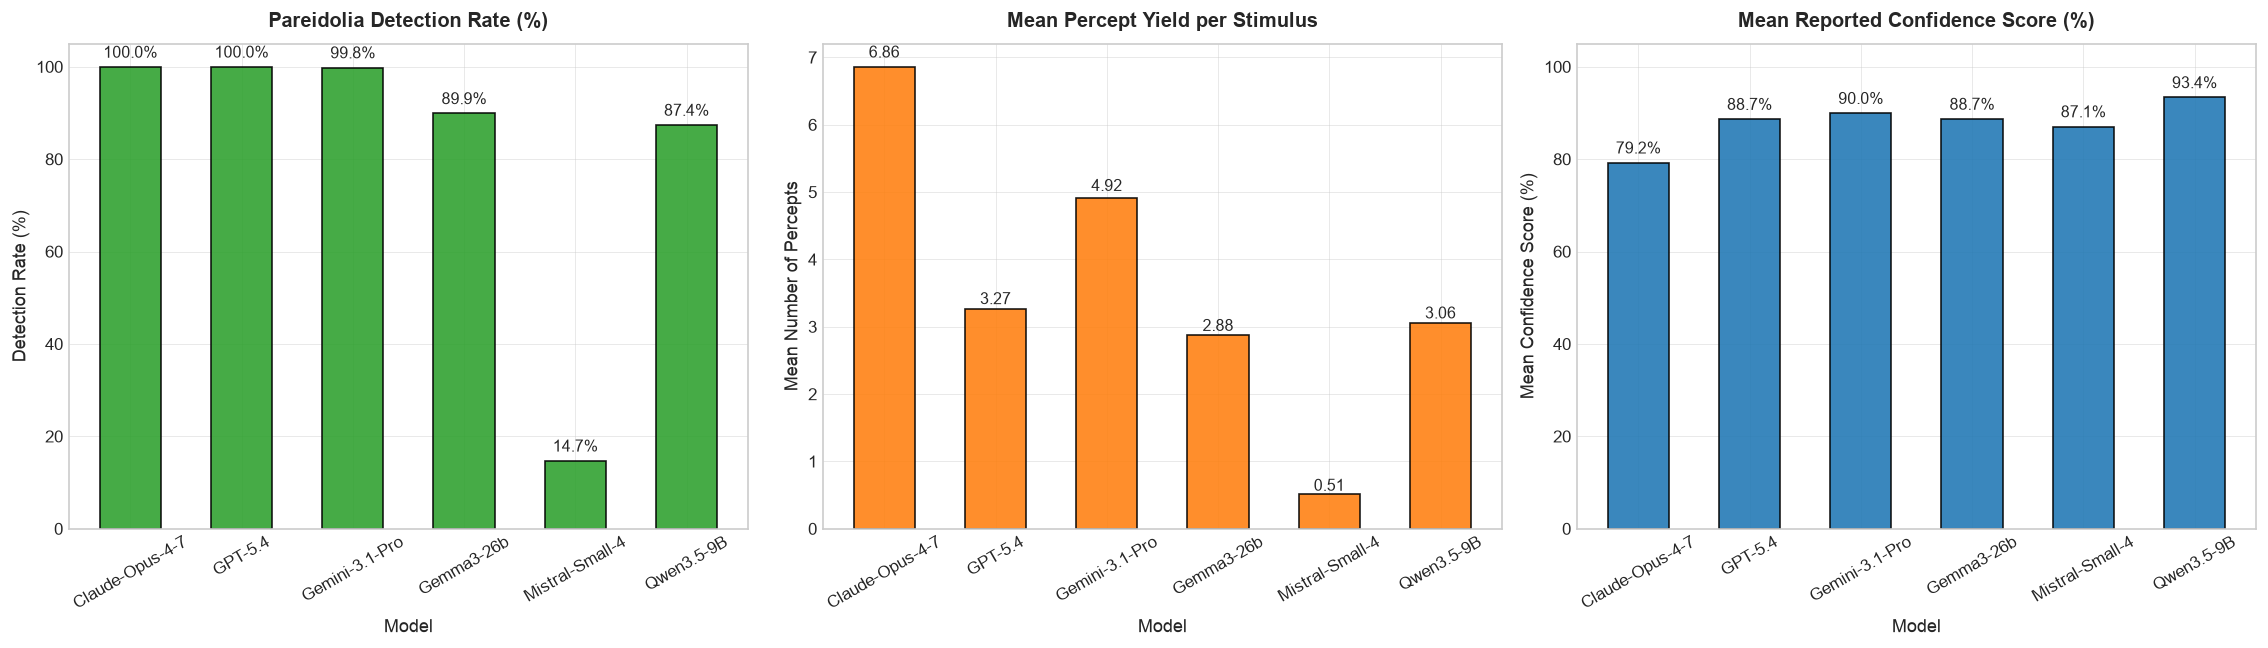

In [52]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("results") / "FaceInThings"
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def safe_parse_confidence(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
    return None

def get_percept_info(row):
    parsed = row.get('image_parsed') or row.get('fractal_parsed') or {}
    labels = []
    confs = []
    if isinstance(parsed, dict) and 'percepts' in parsed:
        percepts = parsed.get('percepts')
        if isinstance(percepts, list):
            for p in percepts:
                if isinstance(p, dict):
                    lbl = str(p.get('label', '')).lower().strip()
                    if lbl:
                        labels.append(lbl)
                    c_val = safe_parse_confidence(p.get('confidence_present'))
                    if c_val is not None:
                        confs.append(c_val)
    mean_conf = float(np.mean(confs)) if confs else np.nan
    return labels, mean_conf

all_records = []
for model_dir in sorted(RESULTS_DIR.iterdir()):
    if model_dir.is_dir():
        model_name = model_dir.name
        main_path = model_dir / "main_results.jsonl"
        if main_path.exists():
            with open(main_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        try:
                            d = json.loads(line)
                            d['model'] = model_name
                            all_records.append(d)
                        except json.JSONDecodeError:
                            pass

if not all_records:
    raise FileNotFoundError("No result files found in results/FaceInThings/")

df_perc = pd.DataFrame(all_records)

percept_data = df_perc.apply(get_percept_info, axis=1)
df_perc['percept_labels'] = [item[0] for item in percept_data]
df_perc['confidence'] = [item[1] for item in percept_data]
df_perc['percept_count'] = df_perc['percept_labels'].apply(len)
df_perc['has_detection'] = df_perc['percept_count'] > 0

# Metrics aggregation per model
metrics_summary = []
for model, grp in df_perc.groupby('model'):
    det_rate = (grp['has_detection'].mean()) * 100
    mean_yield = grp['percept_count'].mean()
    mean_conf = grp['confidence'].dropna().mean()
    metrics_summary.append({
        'model': model,
        'detection_rate': det_rate,
        'mean_yield': mean_yield,
        'mean_confidence': mean_conf
    })

df_metrics = pd.DataFrame(metrics_summary).set_index('model')

print("=" * 80)
print("PAREIDOLIA PERCEPTION OVERVIEW (FaceInThings @ Temp 1.0):")
print("=" * 80)
print(df_metrics.round(2).to_string())
print("=" * 80)

# Colors matching the established palette
c_green = '#2ca02c'
c_orange = '#ff7f0e'
c_blue = '#1f77b4'

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), dpi=120)

# Panel 1: Detection Rate (%)
axes[0].bar(
    df_metrics.index,
    df_metrics['detection_rate'],
    color=c_green,
    edgecolor='black',
    alpha=0.88,
    width=0.55
)
axes[0].set_title("Pareidolia Detection Rate (%)", fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel("Detection Rate (%)", fontsize=11)
axes[0].set_xlabel("Model", fontsize=11)
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=30)
for idx, (m, val) in enumerate(df_metrics['detection_rate'].items()):
    axes[0].text(idx, val + 2.0, f"{val:.1f}%", ha='center', fontsize=9.5)

# Panel 2: Mean Percept Yield per Image
axes[1].bar(
    df_metrics.index,
    df_metrics['mean_yield'],
    color=c_orange,
    edgecolor='black',
    alpha=0.88,
    width=0.55
)
axes[1].set_title("Mean Percept Yield per Stimulus", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel("Mean Number of Percepts", fontsize=11)
axes[1].set_xlabel("Model", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
for idx, (m, val) in enumerate(df_metrics['mean_yield'].items()):
    axes[1].text(idx, val + max(0.05, val * 0.02), f"{val:.2f}", ha='center', fontsize=9.5)

# Panel 3: Mean Perceived Confidence (%)
axes[2].bar(
    df_metrics.index,
    df_metrics['mean_confidence'],
    color=c_blue,
    edgecolor='black',
    alpha=0.88,
    width=0.55
)
axes[2].set_title("Mean Reported Confidence Score (%)", fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel("Mean Confidence Score (%)", fontsize=11)
axes[2].set_xlabel("Model", fontsize=11)
axes[2].set_ylim(0, 105)
axes[2].tick_params(axis='x', rotation=30)
for idx, (m, val) in enumerate(df_metrics['mean_confidence'].items()):
    if not np.isnan(val):
        axes[2].text(idx, val + 2.0, f"{val:.1f}%", ha='center', fontsize=9.5)

plt.tight_layout()
plt.show()